In [72]:
import json
from collections import defaultdict
from tabulate import tabulate
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from numpy import *

def load_entries_to_df(file_path):
    entries = []
    with open(file_path, "r") as f:
        for line in f:
            data = json.loads(line)
            if data.get("type") == "entry":
                instance_name = data.get("entry_name")
                instance = data.get("instance", {})
                features = instance.get("features", {})
                original = instance.get("original_outcome")
                predicted = instance.get("predicted_outcome")

                entry_dict = {
                    "Instance_Name": instance_name,
                    "Original_Outcome": original,
                    "Predicted_Outcome": predicted,
                    **features
                }
                entries.append(entry_dict)
    df = pd.DataFrame(entries)
    return df


def load_and_group_rules(file_path):
    grouped_rules = defaultdict(lambda: defaultdict(list))

    with open(file_path, "r") as f:
        for line in f:
            data = json.loads(line)
            if data.get("type") == "rule":
                premises = data["rule"]["premises"]
                premises_str = " AND ".join(f'{p["attr"]} {p["op"]} {p["val"]}' for p in premises)
                consequence = data["rule"]["consequence"]
                consequence_str = f'{consequence["attr"]} {consequence["op"]} {consequence["val"]}'
                rule_str = f'IF {premises_str} THEN {consequence_str}'

                metrics = data.get("metrics", {})
                rule_dict = {
                    "Premises": premises,
                    "Rule_ID": None,
                    "Rule": rule_str,
                    "Cov": round(metrics.get("coverage", 0), 5),
                    "Cov_class": round(metrics.get("local_class_coverage", 0), 5),
                    "Pre": round(metrics.get("precision", 0), 5),
                    "Len": metrics.get("rule_length", 0),
                    "Reject": metrics.get("rejected", 0),
                    "Elapsed_time": round(metrics.get("elapsed_time", 0), 5),
                    "Iter_Limit": data.get("at_limit", False)
                }

                instance_name = data.get("entry_name")
                explainer = data.get("explainer")
                grouped_rules[instance_name][explainer].append(rule_dict)

    return grouped_rules

def grouped_rules_to_df(grouped_rules):
    rows = []
    for instance_name, explainers_dict in grouped_rules.items():
        for explainer, rules_list in explainers_dict.items():
           for i, rule_dict in enumerate(rules_list, start=1):
                row = {
                    "Instance_Name": instance_name,
                    "Explainer": explainer,
                }
                row.update(rule_dict)
                row["Rule_ID"] = f"{explainer}{i}"
                rows.append(row)
    return pd.DataFrame(rows)


def filter_non_dominated(df, cov_col='Cov', pre_col='Pre'):
    non_dominated_indices = []
    for i, row_i in df.iterrows():
        dominated = False
        for j, row_j in df.iterrows():
            if i != j:
                if (row_j[cov_col] >= row_i[cov_col] and
                    row_j[pre_col] >= row_i[pre_col] and
                    (row_j[cov_col] > row_i[cov_col] or row_j[pre_col] > row_i[pre_col])):
                    dominated = True
                    break
        if not dominated:
            non_dominated_indices.append(i)

    return df.loc[non_dominated_indices].reset_index(drop=True).copy()

def ideal_point_rule_2d(df, col_1='Cov', col_1_prop="gain", col_2='Pre', col_2_prop="gain"):
    if not df.empty:
        if col_1_prop == "loss":
            col_1_ideal = df[col_1].min()
        else:
            col_1_ideal = df[col_1].max()
        if col_2_prop == "loss":
            col_2_ideal = df[col_2].min()
        else:
            col_2_ideal = df[col_2].max()
            
        df['Distance_idp_eucl'] = numpy.sqrt((df[col_1] - col_1_ideal)**2 + (df[col_2] - col_2_ideal)**2)
        
        return df['Distance_idp_eucl'].idxmin(), [col_1_ideal,col_2_ideal]

def ideal_point_rule_3d(df, col_1='Cov_class', col_1_prop="gain", col_2='Pre', col_2_prop="gain", col_3='Len', col_3_prop="loss"):
    if not df.empty:
        if col_1_prop == "loss":
            col_1_ideal = df[col_1].min()
        else:
            col_1_ideal = df[col_1].max()
        if col_2_prop == "loss":
            col_2_ideal = df[col_2].min()
        else:
            col_2_ideal = df[col_2].max()
        if col_3_prop == "loss":
            col_3_ideal = df[col_2].min()
        else:
            col_3_ideal = df[col_2].max()
            
        df['Distance_idp_eucl'] = numpy.sqrt((df[col_1] - col_1_ideal)**2 + (df[col_2] - col_2_ideal)**2 + (df[col_3] - col_3_ideal)**2)
        # df.loc[df['Distance_idp_eucl'].idxmin()]
        return df['Distance_idp_eucl'].idxmin(), [col_1_ideal,col_2_ideal,col_3_ideal]

def filter_non_dominated_3d(df, cov_col='Cov_class', pre_col='Pre', len_col='Len'):
    # convert to numpy for speed
    data = df[[cov_col, pre_col, len_col]].to_numpy()

    non_dominated_mask = []
    for i, candidate in enumerate(data):
        dominated = False
        for j, other in enumerate(data):
            if i == j:
                continue
            # check if 'other' dominates 'candidate':
            # other is better or equal in all objectives AND strictly better in at least one
            # for cov_col and pre_col (to maximize): other >= candidate
            # for len_col (to minimize): other <= candidate
            if (other[0] >= candidate[0] and
                other[1] >= candidate[1] and
                other[2] <= candidate[2] and
                (other[0] > candidate[0] or other[1] > candidate[1] or other[2] < candidate[2])):
                dominated = True
                break
        non_dominated_mask.append(not dominated)

    return df.loc[non_dominated_mask].reset_index(drop=True).copy()
    
def plot_non_dominated_rules(non_dominated_rules, instance_name, coord_1 = 'Cov', coord_2 = 'Pre'):
    ideal_rule_idx, ideal_point = ideal_point_rule_2d(non_dominated_rules)
    ideal_rule = non_dominated_rules.loc[ideal_rule_idx]
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=non_dominated_rules,
        x= coord_1,
        y= coord_2,
        hue='Explainer',
        style='Explainer',
        palette='tab10',
        s=100
    )

    plt.scatter(
        ideal_point[0], ideal_point[1],
        color='black',
        marker='X',
        s=100,
        label='Ideal Point'
    )

    plt.plot(
        [ideal_point[0], ideal_rule[coord_1]],
        [ideal_point[1], ideal_rule[coord_2]],
        'k--',  # black dashed line
        linewidth=1.5
    )

    plt.title(f"Non-dominated Rules for Instance {instance_name} (Coverage ↑, Precision ↑)")
    plt.xlabel("Coverage")
    plt.ylabel("Precision")
    plt.legend(title='Explainer', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def count_unique_attributes_from_rules(df_rules):
    attr_counter = Counter()

    for premises in df_rules['Premises']:
        seen_attrs = set()
        for cond in premises:
            attr = cond['attr']
            seen_attrs.add(attr)
        for attr in seen_attrs:
            attr_counter[attr] += 1  # count only once per rule
    return dict(attr_counter)

def build_attr_usage_df(df_rules):
    rows = []
    for explainer, group in df_rules.groupby('Explainer'):
        attr_counts = count_unique_attributes_from_rules(group)
        for attr, count in attr_counts.items():
            rows.append({"Explainer": explainer, "Feature": attr, "Count": count})
    return pd.DataFrame(rows)

def plot_feature_usage_heatmap(df: pd.DataFrame,
                               feature_col: str,
                               explainer_col: str,
                               count_col: str,
                               all_features: list,
                               vmax: float = None,
                               figsize=(10,8),
                               cmap='YlOrRd'):

    if df.empty:
        print("Empty dataframe: nothing to plot.")
        return
    # pivot table with counts: rows=features, columns=explainers
    heatmap_data = df.pivot_table(index=feature_col, columns=explainer_col, values=count_col, fill_value=0)
    heatmap_data = heatmap_data.reindex(all_features, fill_value=0)

    explainers_with_features = heatmap_data.columns.tolist()
    top_feature_names = heatmap_data.index.tolist()
    actual_max_count = heatmap_data.values.max()
    theoretical_max = vmax if vmax is not None else actual_max_count

    if heatmap_data is not None and theoretical_max > 0:
        plt.figure(figsize=figsize)
        plt.imshow(heatmap_data, cmap=cmap, vmax=theoretical_max, aspect='auto')
        plt.colorbar(label='Rule Count')
        plt.xticks(ticks=range(len(explainers_with_features)), labels=explainers_with_features, rotation=45, ha='right')
        plt.yticks(ticks=range(len(top_feature_names)), labels=top_feature_names)
        plt.title(f'Feature Usage Across Explainers\n(Scale: 0 to {theoretical_max}, Actual max: {actual_max_count})')
        plt.tight_layout()
        plt.show()
    else:
        print("No data to display or vmax <= 0.")

def plot_rules_comparison(all_rules, filtered_rules, instance_name, coord_1 = 'Cov', coord_2 = 'Pre'):
    plt.figure(figsize=(8,6))

    # palette for explainers across both datasets
    explainers = sorted(all_rules['Explainer'].unique())
    palette = sns.color_palette('tab10', n_colors=len(explainers))
    explainer_palette = dict(zip(explainers, palette))
    ideal_rule_idx, ideal_point = ideal_point_rule_2d(filtered_rules)
    ideal_rule = filtered_rules.loc[ideal_rule_idx]
    # all rules - circles
    sns.scatterplot(
        data=all_rules,
        x=coord_1,
        y=coord_2,
        hue='Explainer',
        palette=explainer_palette,
        s=60,
        alpha=0.5,
        marker='o'
    )

    # filtered rules - X markers with edgecolors
    sns.scatterplot(
        data=filtered_rules,
        x=coord_1,
        y=coord_2,
        hue='Explainer',
        palette=explainer_palette,
        s=120,
        marker='X',
        edgecolor='black'
    )

    plt.scatter(
        ideal_point[0], ideal_point[1],
        color='black',
        marker='X',
        s=100,
        label='Ideal Point'
    )

    plt.plot(
        [ideal_point[0], ideal_rule[coord_1]],
        [ideal_point[1], ideal_rule[coord_2]],
        'k--',  # black dashed line
        linewidth=1.5
    )

    # lines connecting filtered rules sorted by Coverage
    filtered_sorted = filtered_rules.sort_values(by=coord_1)
    plt.plot(filtered_sorted[coord_1], filtered_sorted[coord_2], color='gray', linestyle='--', linewidth=1)

    plt.title(f"Rules for Instance {instance_name} (Coverage ↑, Precision ↑)")
    plt.xlabel("Coverage")
    plt.ylabel("Precision")

    handles, labels = plt.gca().get_legend_handles_labels()

    by_label = dict(zip(labels, handles))

    plt.legend(by_label.values(), by_label.keys(), title='Explainer', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

def summarize_explainer_metrics_with_global_average(explainer_dict):
    summary = {}
    all_rows = []

    for explainer, metrics_list in explainer_dict.items():
        df = pd.DataFrame(metrics_list)
        summary[explainer] = df.mean()
        all_rows.append(df)

    df_summary = pd.DataFrame(summary).T

    global_df = pd.concat(all_rows, ignore_index=True)
    df_summary.loc["Global_Average"] = global_df.mean()

    return df_summary

def highlight_row(s, highlight_idx):
    return ['font-weight: bold' if s.name == highlight_idx else '' for _ in s]

In [87]:
from IPython.display import display, Markdown
pd.set_option('display.max_colwidth', None)

def analyze_results(rules_log, entries_log, path = "./experiments_log/", min_cov = 0.1, min_cov_class = 0.1, min_pre = 0.1):
    rules_grouped = load_and_group_rules(path + rules_log)
    df_instances = load_entries_to_df(path + entries_log)
    df_rules = grouped_rules_to_df(rules_grouped)
    instance_names = df_rules['Instance_Name'].unique()
    filtered_counts = defaultdict(list)
    non_dom1_by_explainer = defaultdict(list)
    non_dom2_by_explainer = defaultdict(list)
    filtered_counts_by_explainer = {
        'Correct Prediction': defaultdict(list),
        'Threshold Filter': defaultdict(list),
        'Non-dominated 1': defaultdict(list),
        'Non-dominated 2': defaultdict(list),
    }
    agg_all_dom1 = []
    agg_all_dom2 = []
    
    for i, instance_name in enumerate(instance_names, start=1):
        max_rules = df_rules[df_rules['Instance_Name'] == instance_name].groupby('Explainer').size().max()
        orig = df_instances.loc[df_instances['Instance_Name'] == instance_name, "Original_Outcome"].iloc[0]
        pred = df_instances.loc[df_instances['Instance_Name'] == instance_name, "Predicted_Outcome"].iloc[0]
        display(Markdown(f"## Instance {instance_name} (Original: {orig} , Predicted: {pred})"))
        instance = df_instances[df_instances['Instance_Name'] == instance_name]
        exclude_cols = ['Instance_Name', 'Original_Outcome', 'Predicted_Outcome']
        attributes = [col for col in instance.columns if col not in exclude_cols]
        display(instance.drop(columns=['Instance_Name', 'Original_Outcome', 'Predicted_Outcome']).T.rename(columns={df_instances[df_instances['Instance_Name'] == instance_name].index[0]: 'Value'}))
        
        display(Markdown(f"### Rules for Instance {instance_name}"))
        display(df_rules[df_rules['Instance_Name'] == instance_name].drop(columns=["Premises"]).reset_index(drop=True))
       
        display(Markdown(f"### Rules for Instance {instance_name}, Correct Prediction"))
        original_outcome = df_instances.loc[df_instances['Instance_Name'] == instance_name, 'Original_Outcome'].values[0]
        correct_pred_rules = df_rules[
        (df_rules['Instance_Name'] == instance_name) &
        (df_rules['Rule'].str.contains(f'class = {original_outcome}', na=False))
        ]
        display(correct_pred_rules.drop(columns=["Premises"]).reset_index(drop=True))

        display(Markdown(f"### Rules for Instance {instance_name}, Min_treshold (Cov {min_cov}, Cov_class {min_cov_class}, Pre {min_pre})"))
        tresholded_rules = correct_pred_rules[
        (correct_pred_rules['Cov'] >= min_cov) &
        (correct_pred_rules['Cov_class'] >= min_cov_class) &
        (correct_pred_rules['Pre'] >= min_pre)
        ]
        display(tresholded_rules.drop(columns=["Premises"]).reset_index(drop=True))
    

        non_dominated_rules1 = filter_non_dominated(tresholded_rules)
        if not non_dominated_rules1.empty:
            ideal_rule_idx, ideal_point = ideal_point_rule_2d(non_dominated_rules1)
        display(Markdown(f"### Rules for Instance {instance_name}, Non-dominated (Cov↑, Pre↑), Ideal (Cov: {ideal_point[0]}, Pre: {ideal_point[1]})"))

        
        df_display = non_dominated_rules1.drop(columns=["Premises"]).reset_index(drop=True)

        display(df_display.style.apply(highlight_row, highlight_idx=ideal_rule_idx, axis=1))
        if not non_dominated_rules1.empty:
            plot_non_dominated_rules(non_dominated_rules1, instance_name)
            plot_rules_comparison(all_rules=df_rules[df_rules['Instance_Name'] == instance_name],
                                          filtered_rules=non_dominated_rules1,
                                          instance_name=instance_name)
        
        agg_df = build_attr_usage_df(non_dominated_rules1)
        agg_all_dom1.append(agg_df)
        plot_feature_usage_heatmap(agg_df, feature_col="Feature", explainer_col="Explainer", count_col="Count", all_features=attributes, vmax = max_rules)

        non_dominated_rules2 = filter_non_dominated_3d(tresholded_rules)
        if not non_dominated_rules2.empty:
            ideal_rule_idx, ideal_point = ideal_point_rule_3d(non_dominated_rules2)
        display(Markdown(f"### Rules for Instance {instance_name}, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: {ideal_point[0]}, Pre: {ideal_point[1]}, Len: {ideal_point[2]})"))
        df_display = non_dominated_rules2.drop(columns=["Premises"]).reset_index(drop=True)

        display(df_display.style.apply(highlight_row, highlight_idx=ideal_rule_idx, axis=1))
        agg_df = build_attr_usage_df(non_dominated_rules2)
        agg_all_dom2.append(agg_df)
        plot_feature_usage_heatmap(agg_df, feature_col="Feature", explainer_col="Explainer", count_col="Count", all_features=attributes, vmax = max_rules)
    
        all_rules_count = len(df_rules[df_rules['Instance_Name'] == instance_name])
        correct_pred_count = len(correct_pred_rules)
        tresholded_count = len(tresholded_rules)
        non_dom1_count = len(non_dominated_rules1)
        non_dom2_count = len(non_dominated_rules2)
        
        # filtered counts
        filtered_counts['Correct Prediction'].append(all_rules_count - correct_pred_count)
        filtered_counts['Threshold Filter'].append(correct_pred_count - tresholded_count)
        filtered_counts['Non-dominated 1'].append(tresholded_count - non_dom1_count)
        filtered_counts['Non-dominated 2'].append(tresholded_count - non_dom2_count)
    
        original_rules_instance = df_rules[df_rules['Instance_Name'] == instance_name]
        orig_counts = original_rules_instance['Explainer'].value_counts()
        correct_pred_counts = correct_pred_rules['Explainer'].value_counts()
        filtered_per_explainer_cp = (orig_counts - correct_pred_counts).fillna(orig_counts).astype(int)
        for explainer, count in filtered_per_explainer_cp.items():
            filtered_counts_by_explainer['Correct Prediction'][explainer].append(count)
        tresholded_counts = tresholded_rules['Explainer'].value_counts()
        filtered_per_explainer_thresh = (correct_pred_counts - tresholded_counts).fillna(correct_pred_counts).astype(int)
        for explainer, count in filtered_per_explainer_thresh.items():
            filtered_counts_by_explainer['Threshold Filter'][explainer].append(count)
        non_dom1_counts = non_dominated_rules1['Explainer'].value_counts()
        filtered_per_explainer_non_dom1 = (tresholded_counts - non_dom1_counts).fillna(tresholded_counts).astype(int)
        for explainer, count in filtered_per_explainer_non_dom1.items():
            filtered_counts_by_explainer['Non-dominated 1'][explainer].append(count)
        non_dominated_rules2 = filter_non_dominated_3d(tresholded_rules)
        non_dom2_counts = non_dominated_rules2['Explainer'].value_counts()
        filtered_per_explainer_non_dom2 = (tresholded_counts - non_dom2_counts).fillna(tresholded_counts).astype(int)
        for explainer, count in filtered_per_explainer_non_dom2.items():
            filtered_counts_by_explainer['Non-dominated 2'][explainer].append(count)
    
        
        if not non_dominated_rules1.empty:
            for explainer, group in non_dominated_rules1.groupby("Explainer"):
                non_dom1_by_explainer[explainer].append(
                    group[['Pre', 'Cov', 'Cov_class', 'Len', 'Reject', 'Elapsed_time']].mean()
                )
    
        if not non_dominated_rules2.empty:
            for explainer, group in non_dominated_rules2.groupby("Explainer"):
                non_dom2_by_explainer[explainer].append(
                    group[['Pre', 'Cov', 'Cov_class', 'Len', 'Reject', 'Elapsed_time']].mean()
                )
        
    
    # average filtered rules per stage
    display(Markdown("### Average Number of Filtered Rules at Each Step"))
    filtration_summary = pd.DataFrame({stage: pd.Series(values).mean() for stage, values in filtered_counts.items()}, index=["Avg Filtered"]).T
    # display(filtration_summary)
    step_avg_dfs = {}
    for step, explainer_dict in filtered_counts_by_explainer.items():
        df = pd.DataFrame({expl: pd.Series(counts) for expl, counts in explainer_dict.items()})
        step_avg_dfs[step] = df.mean().rename(step)  # Series with index=explainer, values=avg filtered
    
    combined_df = pd.concat(step_avg_dfs.values(), axis=1).fillna(0)
    combined_df.index.name = 'Explainer'
    combined_df.columns = [f"Avg Filtered ({col})" for col in combined_df.columns]
    
    mapping = {
        'Correct Prediction': 'Avg Filtered (Correct Prediction)',
        'Threshold Filter': 'Avg Filtered (Threshold Filter)',
        'Non-dominated 1': 'Avg Filtered (Non-dominated 1)',
        'Non-dominated 2': 'Avg Filtered (Non-dominated 2)'
    }
    new_row = {}
    for step, col_name in mapping.items():
        new_row[col_name] = filtration_summary.loc[step, 'Avg Filtered']
    
    combined_df.loc['Overall Average'] = pd.Series(new_row)
    display(combined_df)
    
    # average metrics for non-dominated rules
    display(Markdown("### Average Metrics for Non-Dominated Rules (Cov↑, Pre↑)"))
    explainer_summary1 = summarize_explainer_metrics_with_global_average(non_dom1_by_explainer)
    display(explainer_summary1)

    display(Markdown("### Average Metrics for Non-Dominated Rules (Cov_class↑, Pre↑, Len↓)"))
    explainer_summary2 = summarize_explainer_metrics_with_global_average(non_dom2_by_explainer)
    display(explainer_summary2)

    agg_all_dom1_df = pd.concat(agg_all_dom1).groupby(['Feature', 'Explainer']).sum().reset_index()
    agg_all_dom2_df = pd.concat(agg_all_dom2).groupby(['Feature', 'Explainer']).sum().reset_index()

    all_features = [col for col in df_instances.columns if col not in ['Instance_Name', 'Original_Outcome', 'Predicted_Outcome']]
    
    display(Markdown("## Overall Heatmap – Non-dominated Rules (Cov↑, Pre↑)"))
    plot_feature_usage_heatmap(agg_all_dom1_df, feature_col="Feature", explainer_col="Explainer", count_col="Count", all_features=all_features, vmax =max_rules * len(instance_names))
    
    display(Markdown("## Overall Heatmap – Non-dominated Rules (Cov_class↑, Pre↑, Len↓)"))
    plot_feature_usage_heatmap(agg_all_dom2_df, feature_col="Feature", explainer_col="Explainer", count_col="Count", all_features=all_features, vmax =max_rules * len(instance_names))

## Instance 5988 (Original: <=50K , Predicted: <=50K)

,Value
age,41.0
workclass,Private
education,Some-college
education.num,10
marital.status,Married-civ-spouse
occupation,Farming-fishing
relationship,Husband
race,White
sex,Male
capital.gain,0.0


### Rules for Instance 5988

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,5988,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND hours.per.week <= 45.0 AND occupation = Farming-fishing THEN class = <=50K,0.01571,0.01971,0.95251,4,0,1.54453,False
1,5988,ANCHOR,ANCHOR2,IF capital.gain <= 0.0 AND hours.per.week <= 45.0 AND occupation = Farming-fishing THEN class = <=50K,0.01615,0.02023,0.95109,3,0,1.68503,False
2,5988,ANCHOR,ANCHOR3,IF age <= 47.0 AND capital.gain <= 0.0 AND capital.loss <= 0.0 AND occupation = Farming-fishing THEN class = <=50K,0.01816,0.02254,0.94203,4,0,1.55565,False
3,5988,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND hours.per.week <= 40.0 AND occupation = Farming-fishing THEN class = <=50K,0.01474,0.01855,0.95536,3,3,6.51489,False
4,5988,ANCHOR,ANCHOR5,IF age <= 47.0 AND capital.gain <= 0.0 AND occupation = Farming-fishing THEN class = <=50K,0.01887,0.02306,0.92791,3,0,1.49903,False
5,5988,LORE,LORE1,IF hours.per.week <= 40.0 AND occupation = Farming-fishing THEN class = <=50K,0.01571,0.01936,0.93575,2,0,42.03551,False
6,5988,LORE,LORE2,IF hours.per.week <= 32.0 AND occupation = Farming-fishing THEN class = <=50K,0.00461,0.00589,0.97143,2,0,40.73262,False
7,5988,LORE,LORE3,IF age > 39.0 AND age <= 41.0 THEN class = >50K,0.04866,0.06868,0.33995,2,0,35.27999,False
8,5988,LORE,LORE4,IF hours.per.week <= 50.0 AND occupation = Farming-fishing THEN class = <=50K,0.02119,0.02560,0.91718,2,0,35.37699,False
9,5988,LORE,LORE5,IF hours.per.week <= 35.0 THEN class = <=50K,0.21231,0.25574,0.91445,1,0,35.56768,False


### Rules for Instance 5988, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,5988,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND hours.per.week <= 45.0 AND occupation = Farming-fishing THEN class = <=50K,0.01571,0.01971,0.95251,4,0,1.54453,False
1,5988,ANCHOR,ANCHOR2,IF capital.gain <= 0.0 AND hours.per.week <= 45.0 AND occupation = Farming-fishing THEN class = <=50K,0.01615,0.02023,0.95109,3,0,1.68503,False
2,5988,ANCHOR,ANCHOR3,IF age <= 47.0 AND capital.gain <= 0.0 AND capital.loss <= 0.0 AND occupation = Farming-fishing THEN class = <=50K,0.01816,0.02254,0.94203,4,0,1.55565,False
3,5988,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND hours.per.week <= 40.0 AND occupation = Farming-fishing THEN class = <=50K,0.01474,0.01855,0.95536,3,3,6.51489,False
4,5988,ANCHOR,ANCHOR5,IF age <= 47.0 AND capital.gain <= 0.0 AND occupation = Farming-fishing THEN class = <=50K,0.01887,0.02306,0.92791,3,0,1.49903,False
5,5988,LORE,LORE1,IF hours.per.week <= 40.0 AND occupation = Farming-fishing THEN class = <=50K,0.01571,0.01936,0.93575,2,0,42.03551,False
6,5988,LORE,LORE2,IF hours.per.week <= 32.0 AND occupation = Farming-fishing THEN class = <=50K,0.00461,0.00589,0.97143,2,0,40.73262,False
7,5988,LORE,LORE4,IF hours.per.week <= 50.0 AND occupation = Farming-fishing THEN class = <=50K,0.02119,0.02560,0.91718,2,0,35.37699,False
8,5988,LORE,LORE5,IF hours.per.week <= 35.0 THEN class = <=50K,0.21231,0.25574,0.91445,1,0,35.56768,False
9,5988,LORE_SA,LORE_SA1,IF capital.gain <= 2874.854736328125 AND capital.loss <= 2694.723388671875 AND education.num != 15 AND hours.per.week <= 57.859853744506836 AND occupation != Exec-managerial AND occupation != Tech-support AND occupation != Craft-repair AND occupation != Sales THEN class = <=50K,0.52733,0.59903,0.86238,8,0,10.22085,False


### Rules for Instance 5988, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,5988,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND hours.per.week <= 45.0 AND occupation = Farming-fishing THEN class = <=50K,0.01571,0.01971,0.95251,4,0,1.54453,False
1,5988,ANCHOR,ANCHOR2,IF capital.gain <= 0.0 AND hours.per.week <= 45.0 AND occupation = Farming-fishing THEN class = <=50K,0.01615,0.02023,0.95109,3,0,1.68503,False
2,5988,ANCHOR,ANCHOR3,IF age <= 47.0 AND capital.gain <= 0.0 AND capital.loss <= 0.0 AND occupation = Farming-fishing THEN class = <=50K,0.01816,0.02254,0.94203,4,0,1.55565,False
3,5988,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND hours.per.week <= 40.0 AND occupation = Farming-fishing THEN class = <=50K,0.01474,0.01855,0.95536,3,3,6.51489,False
4,5988,ANCHOR,ANCHOR5,IF age <= 47.0 AND capital.gain <= 0.0 AND occupation = Farming-fishing THEN class = <=50K,0.01887,0.02306,0.92791,3,0,1.49903,False
5,5988,LORE,LORE1,IF hours.per.week <= 40.0 AND occupation = Farming-fishing THEN class = <=50K,0.01571,0.01936,0.93575,2,0,42.03551,False
6,5988,LORE,LORE4,IF hours.per.week <= 50.0 AND occupation = Farming-fishing THEN class = <=50K,0.02119,0.02560,0.91718,2,0,35.37699,False
7,5988,LORE,LORE5,IF hours.per.week <= 35.0 THEN class = <=50K,0.21231,0.25574,0.91445,1,0,35.56768,False
8,5988,LORE_SA,LORE_SA1,IF capital.gain <= 2874.854736328125 AND capital.loss <= 2694.723388671875 AND education.num != 15 AND hours.per.week <= 57.859853744506836 AND occupation != Exec-managerial AND occupation != Tech-support AND occupation != Craft-repair AND occupation != Sales THEN class = <=50K,0.52733,0.59903,0.86238,8,0,10.22085,False
9,5988,LORE_SA,LORE_SA2,IF capital.gain <= 13079.5849609375 AND capital.loss <= 3071.783447265625 AND hours.per.week <= 48.838104248046875 AND occupation = Farming-fishing THEN class = <=50K,0.01742,0.02144,0.93451,4,0,10.33955,False


### Rules for Instance 5988, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.52733, Pre: 0.96386)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,5988,LORE,LORE5,IF hours.per.week <= 35.0 THEN class = <=50K,0.212310,0.255740,0.914450,1,0,35.567680,False,0.318871
1,5988,LORE_SA,LORE_SA1,IF capital.gain <= 2874.854736328125 AND capital.loss <= 2694.723388671875 AND education.num != 15 AND hours.per.week <= 57.859853744506836 AND occupation != Exec-managerial AND occupation != Tech-support AND occupation != Craft-repair AND occupation != Sales THEN class = <=50K,0.527330,0.599030,0.862380,8,0,10.220850,False,0.101480
2,5988,EXPLAN,EXPLAN1,IF hours.per.week <= 30.0 THEN class = <=50K,0.162340,0.199100,0.931080,1,0,0.658970,False,0.366459
3,5988,EXPLAN,EXPLAN2,IF hours.per.week <= 35.0 THEN class = <=50K,0.212310,0.255740,0.914450,1,0,0.662780,False,0.318871
4,5988,EXPLAN,EXPLAN3,IF age <= 49.0 AND hours.per.week <= 30.0 THEN class = <=50K,0.120610,0.151480,0.953440,2,4,3.378510,False,0.406853
5,5988,EXPLAN,EXPLAN4,IF hours.per.week <= 28.0 THEN class = <=50K,0.126140,0.154940,0.932520,1,0,0.749880,False,0.402412
6,5988,EXPLAN,EXPLAN5,IF age <= 41.0 AND hours.per.week <= 34.0 THEN class = <=50K,0.114120,0.144890,0.963860,2,0,1.044090,False,0.413210


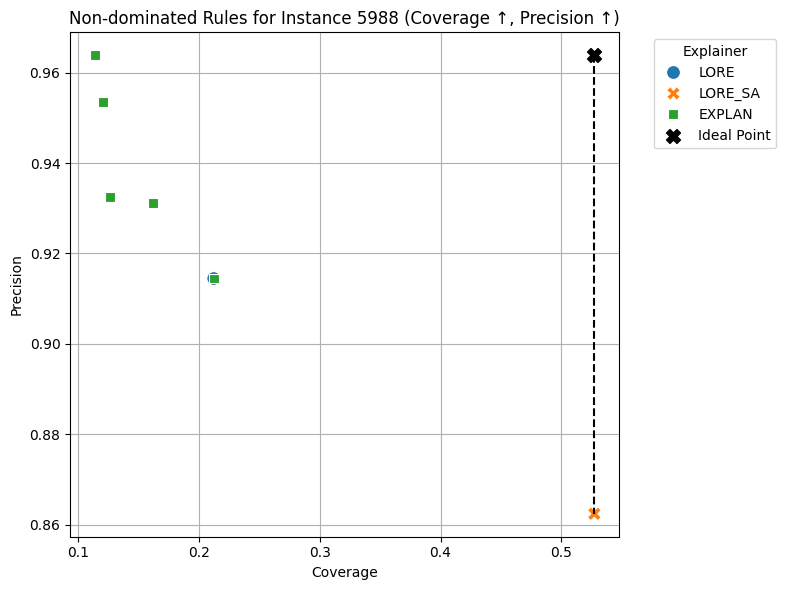

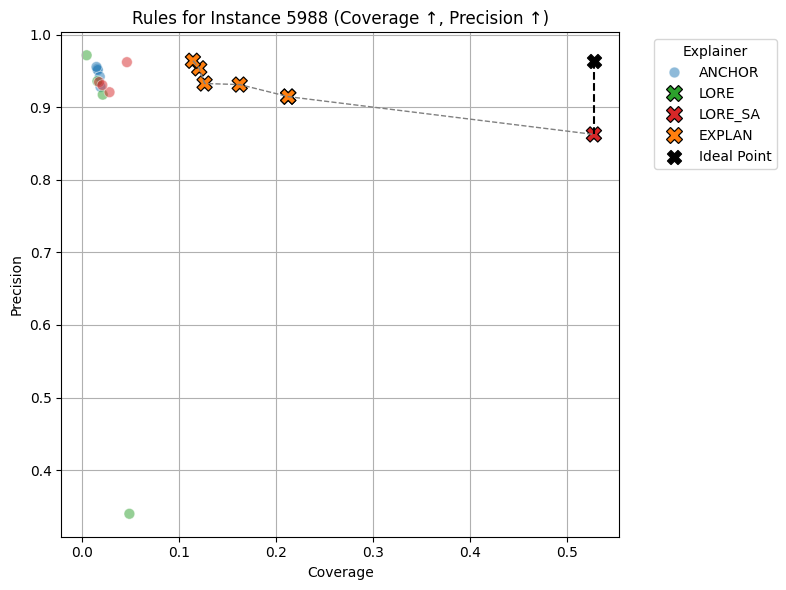

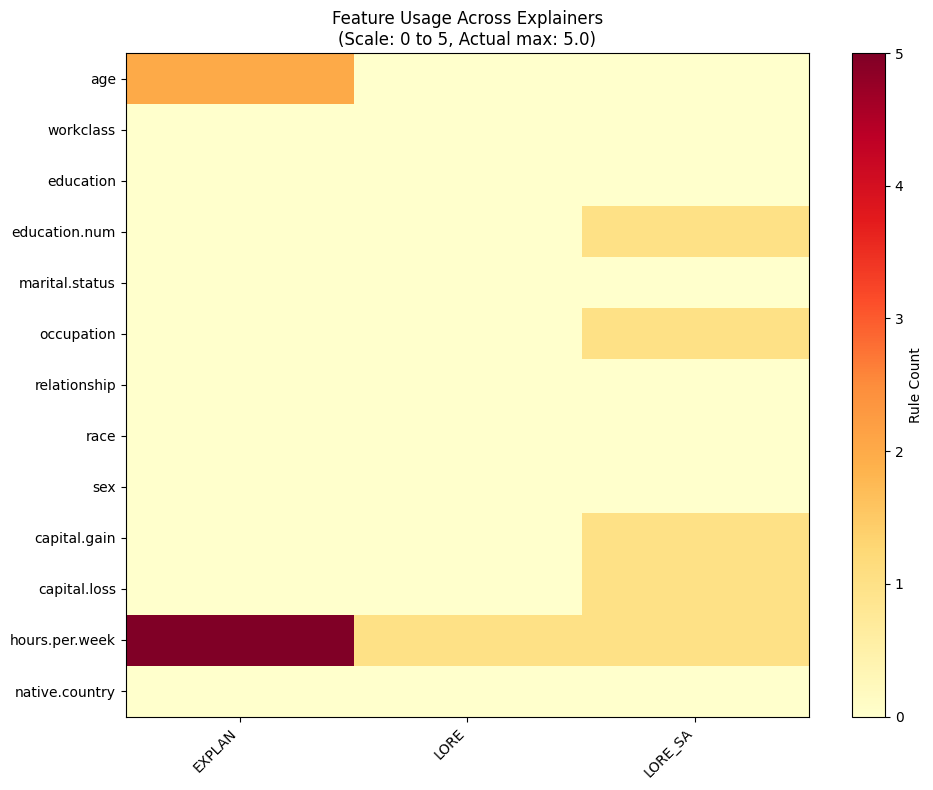

### Rules for Instance 5988, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.59903, Pre: 0.96386, Len: 0.86238)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,5988,LORE,LORE5,IF hours.per.week <= 35.0 THEN class = <=50K,0.212310,0.255740,0.914450,1,0,35.567680,False,0.373134
1,5988,LORE_SA,LORE_SA1,IF capital.gain <= 2874.854736328125 AND capital.loss <= 2694.723388671875 AND education.num != 15 AND hours.per.week <= 57.859853744506836 AND occupation != Exec-managerial AND occupation != Tech-support AND occupation != Craft-repair AND occupation != Sales THEN class = <=50K,0.527330,0.599030,0.862380,8,0,10.220850,False,7.138341
2,5988,EXPLAN,EXPLAN1,IF hours.per.week <= 30.0 THEN class = <=50K,0.162340,0.199100,0.931080,1,0,0.658970,False,0.424214
3,5988,EXPLAN,EXPLAN2,IF hours.per.week <= 35.0 THEN class = <=50K,0.212310,0.255740,0.914450,1,0,0.662780,False,0.373134
4,5988,EXPLAN,EXPLAN3,IF age <= 49.0 AND hours.per.week <= 30.0 THEN class = <=50K,0.120610,0.151480,0.953440,2,4,3.378510,False,1.222534
5,5988,EXPLAN,EXPLAN4,IF hours.per.week <= 28.0 THEN class = <=50K,0.126140,0.154940,0.932520,1,0,0.749880,False,0.465980
6,5988,EXPLAN,EXPLAN5,IF age <= 41.0 AND hours.per.week <= 34.0 THEN class = <=50K,0.114120,0.144890,0.963860,2,0,1.044090,False,1.224917


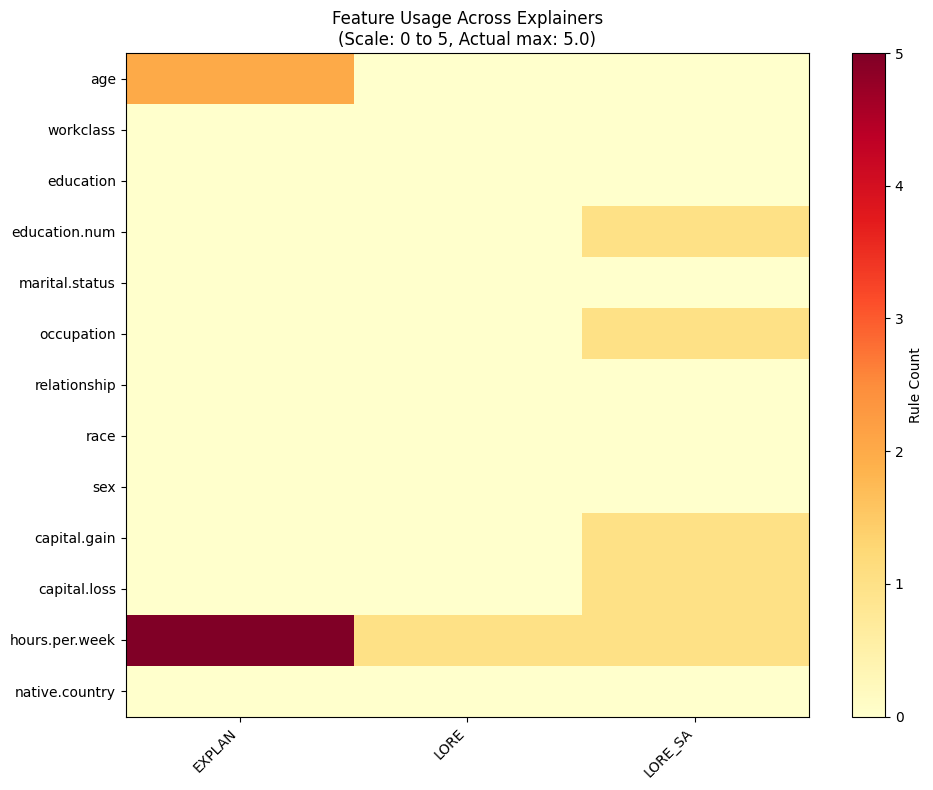

## Instance 18073 (Original: <=50K , Predicted: <=50K)

,Value
age,19.0
workclass,Private
education,12th
education.num,8
marital.status,Never-married
occupation,Handlers-cleaners
relationship,Own-child
race,Black
sex,Female
capital.gain,0.0


### Rules for Instance 18073

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,18073,ANCHOR,ANCHOR1,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,0.76695,False
1,18073,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,0,0.87127,False
2,18073,ANCHOR,ANCHOR3,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.20898,0.27226,0.98908,2,0,0.76020,False
3,18073,ANCHOR,ANCHOR4,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,10,9.61520,True
4,18073,ANCHOR,ANCHOR5,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.20898,0.27226,0.98908,2,0,0.99089,True
5,18073,LORE,LORE1,IF capital.gain <= 16288.190482 THEN class = <=50K,0.99180,0.99954,0.76510,1,0,35.17056,False
6,18073,LORE,LORE2,IF capital.gain <= 7298.0 THEN class = <=50K,0.96363,0.99890,0.78696,1,0,34.90664,False
7,18073,LORE,LORE3,IF age <= 29.75392 AND sex = Female THEN class = <=50K,0.12364,0.15760,0.96771,2,1,87.26376,False
8,18073,LORE,LORE4,IF age <= 39.0 AND marital.status = Never-married THEN class = <=50K,0.28940,0.36855,0.96680,2,0,39.09615,False
9,18073,LORE,LORE5,IF capital.gain <= 15024.0 THEN class = <=50K,0.99162,0.99954,0.76523,1,0,41.67622,False


### Rules for Instance 18073, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,18073,ANCHOR,ANCHOR1,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,0.76695,False
1,18073,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,0,0.87127,False
2,18073,ANCHOR,ANCHOR3,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.20898,0.27226,0.98908,2,0,0.76020,False
3,18073,ANCHOR,ANCHOR4,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,10,9.61520,True
4,18073,ANCHOR,ANCHOR5,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.20898,0.27226,0.98908,2,0,0.99089,True
5,18073,LORE,LORE1,IF capital.gain <= 16288.190482 THEN class = <=50K,0.99180,0.99954,0.76510,1,0,35.17056,False
6,18073,LORE,LORE2,IF capital.gain <= 7298.0 THEN class = <=50K,0.96363,0.99890,0.78696,1,0,34.90664,False
7,18073,LORE,LORE3,IF age <= 29.75392 AND sex = Female THEN class = <=50K,0.12364,0.15760,0.96771,2,1,87.26376,False
8,18073,LORE,LORE4,IF age <= 39.0 AND marital.status = Never-married THEN class = <=50K,0.28940,0.36855,0.96680,2,0,39.09615,False
9,18073,LORE,LORE5,IF capital.gain <= 15024.0 THEN class = <=50K,0.99162,0.99954,0.76523,1,0,41.67622,False


### Rules for Instance 18073, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,18073,ANCHOR,ANCHOR1,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,0.76695,False
1,18073,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,0,0.87127,False
2,18073,ANCHOR,ANCHOR3,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.20898,0.27226,0.98908,2,0,0.76020,False
3,18073,ANCHOR,ANCHOR4,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,10,9.61520,True
4,18073,ANCHOR,ANCHOR5,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.20898,0.27226,0.98908,2,0,0.99089,True
5,18073,LORE,LORE1,IF capital.gain <= 16288.190482 THEN class = <=50K,0.99180,0.99954,0.76510,1,0,35.17056,False
6,18073,LORE,LORE2,IF capital.gain <= 7298.0 THEN class = <=50K,0.96363,0.99890,0.78696,1,0,34.90664,False
7,18073,LORE,LORE3,IF age <= 29.75392 AND sex = Female THEN class = <=50K,0.12364,0.15760,0.96771,2,1,87.26376,False
8,18073,LORE,LORE4,IF age <= 39.0 AND marital.status = Never-married THEN class = <=50K,0.28940,0.36855,0.96680,2,0,39.09615,False
9,18073,LORE,LORE5,IF capital.gain <= 15024.0 THEN class = <=50K,0.99162,0.99954,0.76523,1,0,41.67622,False


### Rules for Instance 18073, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.9918, Pre: 0.99908)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,18073,ANCHOR,ANCHOR1,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.281020,0.358840,0.969400,2,0,0.766950,False,0.711399
1,18073,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.310810,0.392940,0.959770,2,0,0.871270,False,0.682124
2,18073,ANCHOR,ANCHOR3,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.208980,0.272260,0.989080,2,0,0.760200,False,0.782884
3,18073,ANCHOR,ANCHOR4,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.310810,0.392940,0.959770,2,10,9.615200,True,0.682124
4,18073,ANCHOR,ANCHOR5,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.208980,0.272260,0.989080,2,0,0.990890,True,0.782884
5,18073,LORE,LORE1,IF capital.gain <= 16288.190482 THEN class = <=50K,0.991800,0.999540,0.765100,1,0,35.170560,False,0.233980
6,18073,LORE,LORE2,IF capital.gain <= 7298.0 THEN class = <=50K,0.963630,0.998900,0.786960,1,0,34.906640,False,0.213982
7,18073,LORE,LORE4,IF age <= 39.0 AND marital.status = Never-married THEN class = <=50K,0.289400,0.368550,0.966800,2,0,39.096150,False,0.703141
8,18073,LORE,LORE5,IF capital.gain <= 15024.0 THEN class = <=50K,0.991620,0.999540,0.765230,1,0,41.676220,False,0.233850
9,18073,LORE_SA,LORE_SA1,IF capital.gain <= 27709.966796875 AND capital.loss <= 27.544450759887695 AND occupation != Exec-managerial THEN class = <=50K,0.833670,0.888630,0.809220,3,0,12.274840,False,0.247087


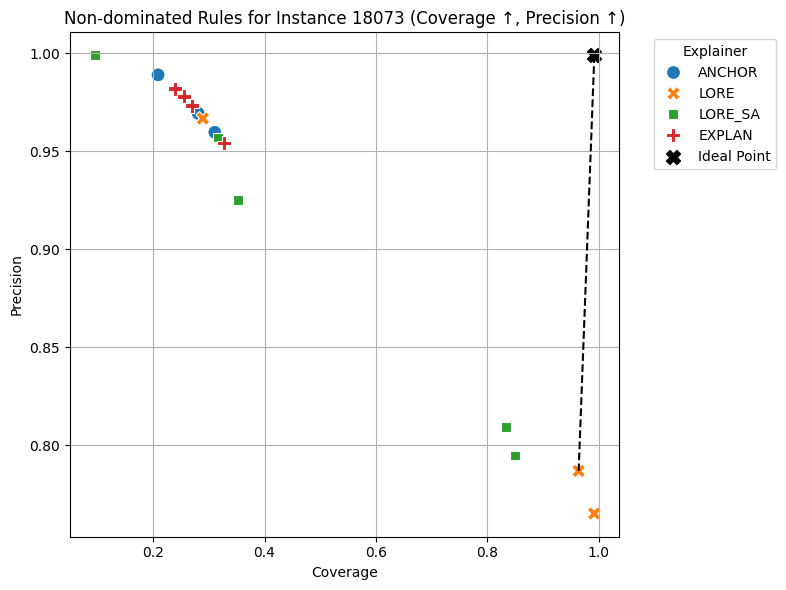

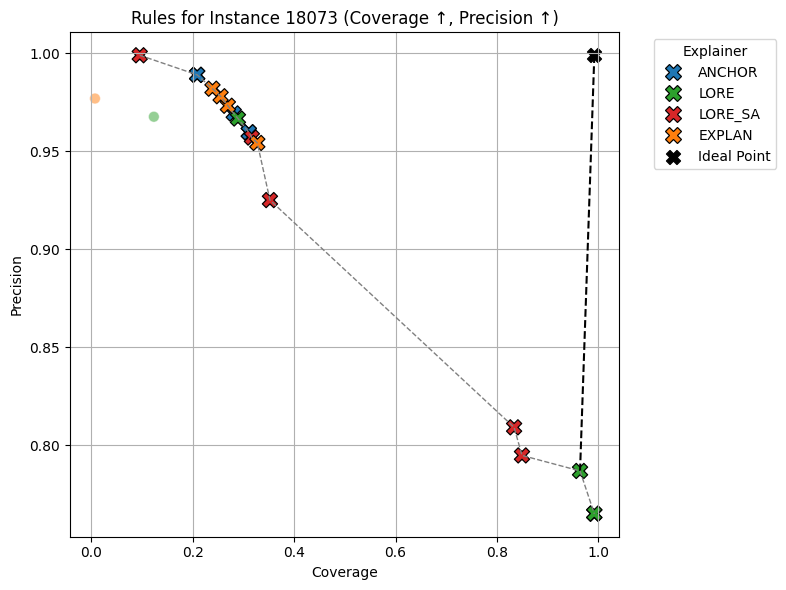

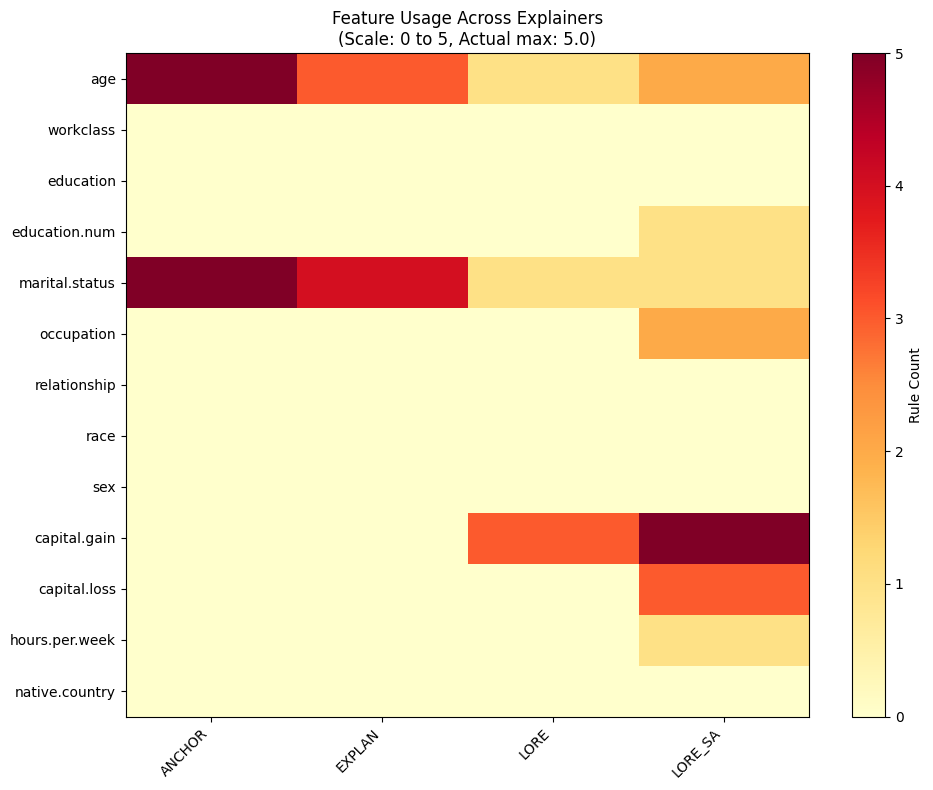

### Rules for Instance 18073, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.99954, Pre: 0.99908, Len: 0.76523)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,18073,ANCHOR,ANCHOR1,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.281020,0.358840,0.969400,2,0,0.766950,False,1.391415
1,18073,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.310810,0.392940,0.959770,2,0,0.871270,False,1.376287
2,18073,ANCHOR,ANCHOR3,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.208980,0.272260,0.989080,2,0,0.760200,False,1.433071
3,18073,ANCHOR,ANCHOR4,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.310810,0.392940,0.959770,2,10,9.615200,True,1.376287
4,18073,ANCHOR,ANCHOR5,IF age <= 28.0 AND marital.status = Never-married THEN class = <=50K,0.208980,0.272260,0.989080,2,0,0.990890,True,1.433071
5,18073,LORE,LORE2,IF capital.gain <= 7298.0 THEN class = <=50K,0.963630,0.998900,0.786960,1,0,34.906640,False,0.316405
6,18073,LORE,LORE4,IF age <= 39.0 AND marital.status = Never-married THEN class = <=50K,0.289400,0.368550,0.966800,2,0,39.096150,False,1.387028
7,18073,LORE,LORE5,IF capital.gain <= 15024.0 THEN class = <=50K,0.991620,0.999540,0.765230,1,0,41.676220,False,0.331365
8,18073,LORE_SA,LORE_SA1,IF capital.gain <= 27709.966796875 AND capital.loss <= 27.544450759887695 AND occupation != Exec-managerial THEN class = <=50K,0.833670,0.888630,0.809220,3,0,12.274840,False,2.245561
9,18073,LORE_SA,LORE_SA2,IF capital.gain <= 23362.1826171875 AND marital.status = Never-married AND occupation != Tech-support THEN class = <=50K,0.316870,0.399470,0.957080,3,0,12.015340,False,2.314313


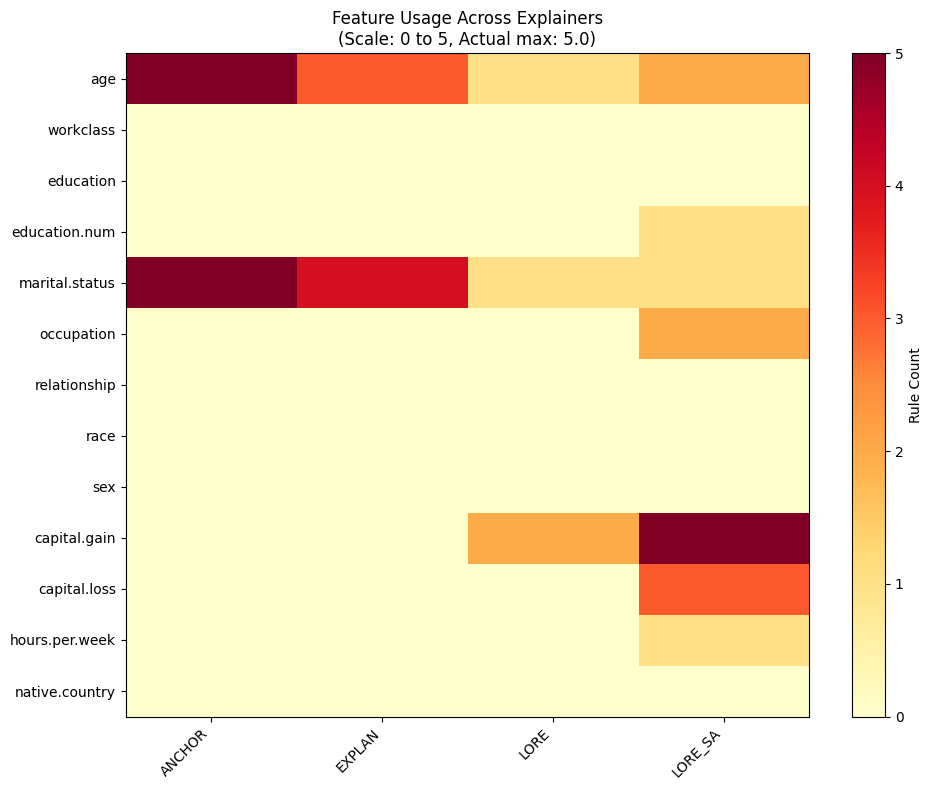

## Instance 652 (Original: >50K , Predicted: >50K)

,Value
age,44.0
workclass,Private
education,Bachelors
education.num,13
marital.status,Married-civ-spouse
occupation,Exec-managerial
relationship,Husband
race,White
sex,Male
capital.gain,0.0


### Rules for Instance 652

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,652,ANCHOR,ANCHOR1,IF age > 37.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND relationship = Husband AND sex = Male THEN class = >50K,0.10061,0.26052,0.62364,6,0,2.87204,False
1,652,ANCHOR,ANCHOR2,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.03699,0.11641,0.75801,3,0,2.56426,False
2,652,ANCHOR,ANCHOR3,IF age > 28.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND occupation = Exec-managerial AND relationship = Husband AND sex = Male THEN class = >50K,0.05928,0.17562,0.71355,6,0,3.11245,False
3,652,ANCHOR,ANCHOR4,IF hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.04076,0.12807,0.75673,3,0,1.66236,False
4,652,ANCHOR,ANCHOR5,IF capital.loss > 0.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.01400,0.04573,0.78683,4,0,2.65748,False
5,652,LORE,LORE1,IF hours.per.week > 45.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.13693,0.32101,0.56456,2,0,36.74510,False
6,652,LORE,LORE2,IF capital.gain > -6465.102565 AND hours.per.week > 48.0 AND relationship = Husband THEN class = >50K,0.12013,0.28767,0.57670,3,0,35.75363,False
7,652,LORE,LORE3,IF marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.07481,0.21242,0.68387,2,0,35.73498,False
8,652,LORE,LORE4,IF education.num = 13 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.07446,0.20969,0.67826,3,0,35.86532,False
9,652,LORE,LORE5,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.41769,0.81417,0.46943,2,0,35.32609,False


### Rules for Instance 652, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,652,ANCHOR,ANCHOR1,IF age > 37.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND relationship = Husband AND sex = Male THEN class = >50K,0.10061,0.26052,0.62364,6,0,2.87204,False
1,652,ANCHOR,ANCHOR2,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.03699,0.11641,0.75801,3,0,2.56426,False
2,652,ANCHOR,ANCHOR3,IF age > 28.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND occupation = Exec-managerial AND relationship = Husband AND sex = Male THEN class = >50K,0.05928,0.17562,0.71355,6,0,3.11245,False
3,652,ANCHOR,ANCHOR4,IF hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.04076,0.12807,0.75673,3,0,1.66236,False
4,652,ANCHOR,ANCHOR5,IF capital.loss > 0.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.01400,0.04573,0.78683,4,0,2.65748,False
5,652,LORE,LORE1,IF hours.per.week > 45.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.13693,0.32101,0.56456,2,0,36.74510,False
6,652,LORE,LORE2,IF capital.gain > -6465.102565 AND hours.per.week > 48.0 AND relationship = Husband THEN class = >50K,0.12013,0.28767,0.57670,3,0,35.75363,False
7,652,LORE,LORE3,IF marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.07481,0.21242,0.68387,2,0,35.73498,False
8,652,LORE,LORE4,IF education.num = 13 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.07446,0.20969,0.67826,3,0,35.86532,False
9,652,LORE,LORE5,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.41769,0.81417,0.46943,2,0,35.32609,False


### Rules for Instance 652, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,652,ANCHOR,ANCHOR1,IF age > 37.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND relationship = Husband AND sex = Male THEN class = >50K,0.10061,0.26052,0.62364,6,0,2.87204,False
1,652,ANCHOR,ANCHOR2,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.03699,0.11641,0.75801,3,0,2.56426,False
2,652,ANCHOR,ANCHOR3,IF age > 28.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND occupation = Exec-managerial AND relationship = Husband AND sex = Male THEN class = >50K,0.05928,0.17562,0.71355,6,0,3.11245,False
3,652,ANCHOR,ANCHOR4,IF hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.04076,0.12807,0.75673,3,0,1.66236,False
4,652,ANCHOR,ANCHOR5,IF capital.loss > 0.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.01400,0.04573,0.78683,4,0,2.65748,False
5,652,LORE,LORE1,IF hours.per.week > 45.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.13693,0.32101,0.56456,2,0,36.74510,False
6,652,LORE,LORE2,IF capital.gain > -6465.102565 AND hours.per.week > 48.0 AND relationship = Husband THEN class = >50K,0.12013,0.28767,0.57670,3,0,35.75363,False
7,652,LORE,LORE3,IF marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.07481,0.21242,0.68387,2,0,35.73498,False
8,652,LORE,LORE4,IF education.num = 13 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.07446,0.20969,0.67826,3,0,35.86532,False
9,652,LORE,LORE5,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.41769,0.81417,0.46943,2,0,35.32609,False


### Rules for Instance 652, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.95038, Pre: 0.78683)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,652,ANCHOR,ANCHOR1,IF age > 37.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND relationship = Husband AND sex = Male THEN class = >50K,0.100610,0.260520,0.623640,6,0,2.872040,False,0.865298
1,652,ANCHOR,ANCHOR2,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.036990,0.116410,0.758010,3,0,2.564260,False,0.913845
2,652,ANCHOR,ANCHOR4,IF hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.040760,0.128070,0.756730,3,0,1.662360,False,0.910118
3,652,ANCHOR,ANCHOR5,IF capital.loss > 0.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.014000,0.045730,0.786830,4,0,2.657480,False,0.936380
4,652,LORE,LORE1,IF hours.per.week > 45.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.136930,0.321010,0.564560,2,0,36.745100,False,0.843270
5,652,LORE,LORE2,IF capital.gain > -6465.102565 AND hours.per.week > 48.0 AND relationship = Husband THEN class = >50K,0.120130,0.287670,0.576700,3,0,35.753630,False,0.856428
6,652,LORE,LORE3,IF marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.074810,0.212420,0.683870,2,0,35.734980,False,0.881603
7,652,LORE,LORE5,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.417690,0.814170,0.469430,2,0,35.326090,False,0.620082
8,652,LORE_SA,LORE_SA2,IF age > 22.41218376159668 AND education != 7th-8th AND education.num != 4 AND marital.status = Married-civ-spouse AND race != Amer-Indian-Eskimo AND relationship != Own-child THEN class = >50K,0.437210,0.846780,0.466430,6,0,12.558020,False,0.604979
9,652,LORE_SA,LORE_SA3,IF education != 1st-4th AND hours.per.week > 10.932516813278198 AND marital.status = Married-civ-spouse THEN class = >50K,0.449940,0.848240,0.454020,3,0,12.570830,False,0.601001


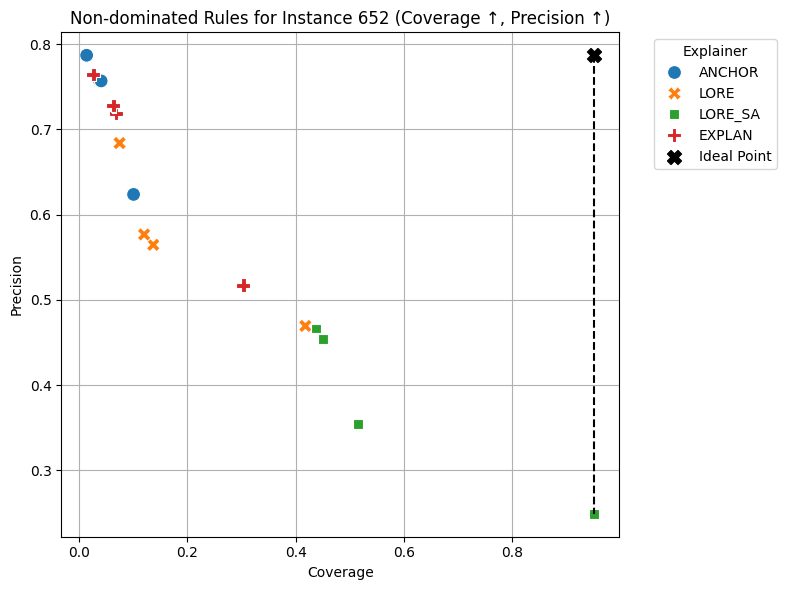

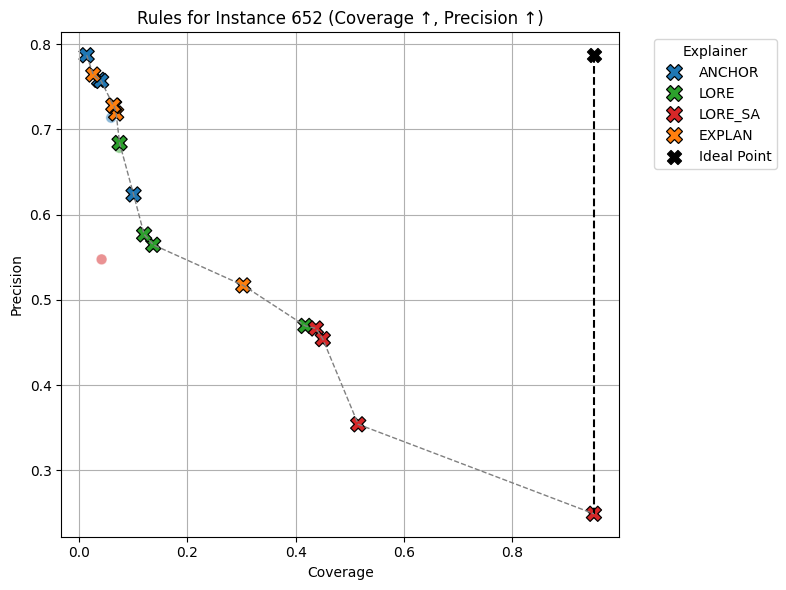

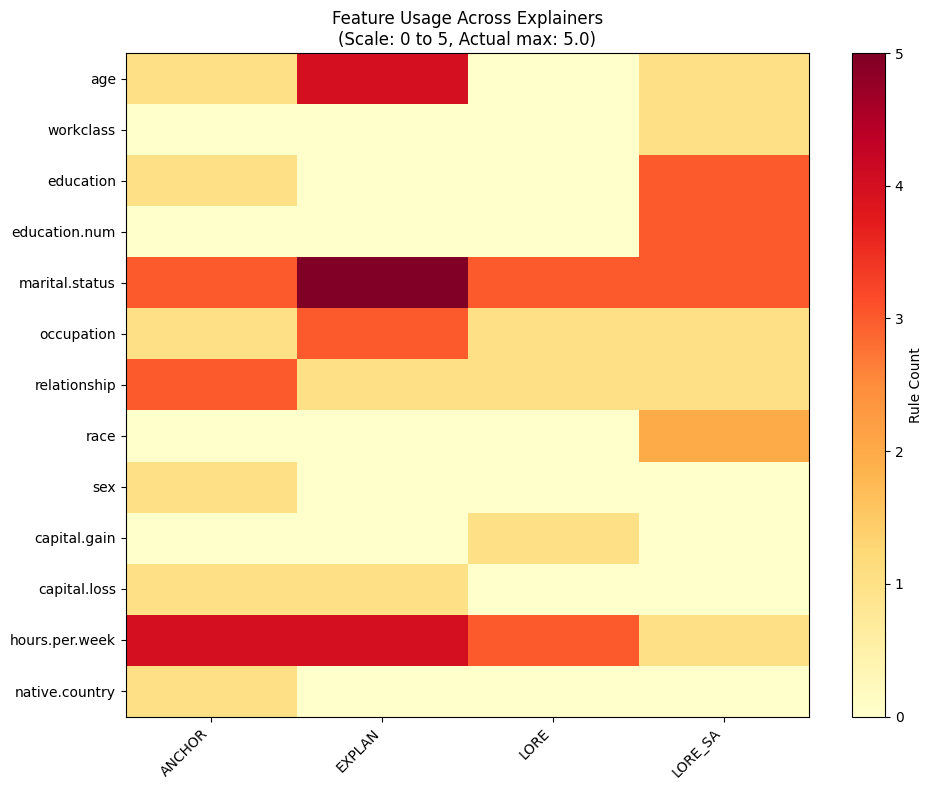

### Rules for Instance 652, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.98306, Pre: 0.78683, Len: 0.24911)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,652,ANCHOR,ANCHOR1,IF age > 37.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND relationship = Husband AND sex = Male THEN class = >50K,0.100610,0.260520,0.623640,6,0,2.872040,False,5.798399
1,652,ANCHOR,ANCHOR2,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.036990,0.116410,0.758010,3,0,2.564260,False,2.884321
2,652,ANCHOR,ANCHOR4,IF hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.040760,0.128070,0.756730,3,0,1.662360,False,2.880852
3,652,ANCHOR,ANCHOR5,IF capital.loss > 0.0 AND hours.per.week > 40.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.014000,0.045730,0.786830,4,0,2.657480,False,3.866234
4,652,LORE,LORE1,IF hours.per.week > 45.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.136930,0.321010,0.564560,2,0,36.745100,False,1.885028
5,652,LORE,LORE2,IF capital.gain > -6465.102565 AND hours.per.week > 48.0 AND relationship = Husband THEN class = >50K,0.120130,0.287670,0.576700,3,0,35.753630,False,2.845192
6,652,LORE,LORE3,IF marital.status = Married-civ-spouse AND occupation = Exec-managerial THEN class = >50K,0.074810,0.212420,0.683870,2,0,35.734980,False,1.915751
7,652,LORE,LORE5,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.417690,0.814170,0.469430,2,0,35.326090,False,1.787423
8,652,LORE_SA,LORE_SA2,IF age > 22.41218376159668 AND education != 7th-8th AND education.num != 4 AND marital.status = Married-civ-spouse AND race != Amer-Indian-Eskimo AND relationship != Own-child THEN class = >50K,0.437210,0.846780,0.466430,6,0,12.558020,False,5.761420
9,652,LORE_SA,LORE_SA3,IF education != 1st-4th AND hours.per.week > 10.932516813278198 AND marital.status = Married-civ-spouse THEN class = >50K,0.449940,0.848240,0.454020,3,0,12.570830,False,2.774227


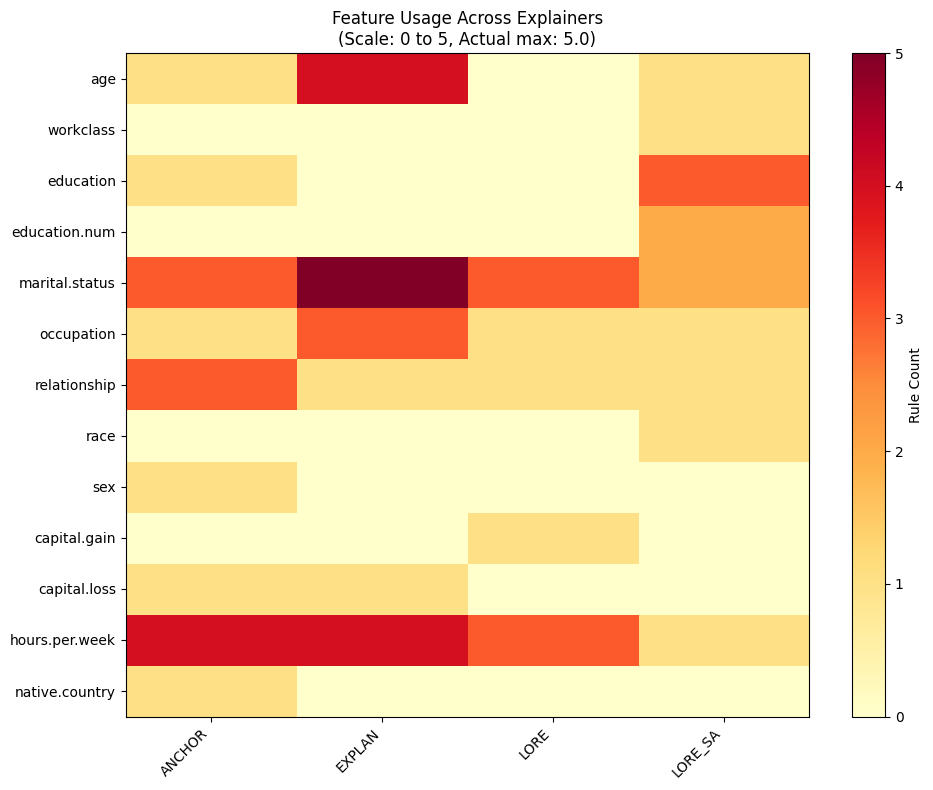

## Instance 2711 (Original: >50K , Predicted: >50K)

,Value
age,39.0
workclass,Private
education,Bachelors
education.num,13
marital.status,Married-civ-spouse
occupation,Sales
relationship,Husband
race,White
sex,Male
capital.gain,7298.0


### Rules for Instance 2711

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,2711,ANCHOR,ANCHOR1,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.03747,0.12115,0.77869,4,0,1.44582,False
1,2711,ANCHOR,ANCHOR2,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.05015,0.15613,0.74978,3,0,1.44391,False
2,2711,ANCHOR,ANCHOR3,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.03773,0.12370,0.78953,4,0,1.64641,False
3,2711,ANCHOR,ANCHOR4,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.03699,0.11641,0.75801,3,1,3.22608,False
4,2711,ANCHOR,ANCHOR5,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.04752,0.15249,0.77285,4,1,3.19524,False
5,2711,LORE,LORE1,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.41769,0.81417,0.46943,2,0,34.78297,False
6,2711,LORE,LORE2,IF age > 29.0 AND hours.per.week > 41.331659 AND marital.status = Married-civ-spouse THEN class = >50K,0.15821,0.38914,0.59235,3,0,35.48339,False
7,2711,LORE,LORE3,IF hours.per.week > 37.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.39944,0.78393,0.47265,2,0,35.60184,False
8,2711,LORE,LORE4,IF age > 35.0 AND hours.per.week > 40.0 THEN class = >50K,0.17853,0.37584,0.50700,2,0,35.21680,False
9,2711,LORE,LORE5,IF hours.per.week > 51.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.07143,0.16415,0.55344,2,0,36.06461,False


### Rules for Instance 2711, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,2711,ANCHOR,ANCHOR1,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.03747,0.12115,0.77869,4,0,1.44582,False
1,2711,ANCHOR,ANCHOR2,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.05015,0.15613,0.74978,3,0,1.44391,False
2,2711,ANCHOR,ANCHOR3,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.03773,0.12370,0.78953,4,0,1.64641,False
3,2711,ANCHOR,ANCHOR4,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.03699,0.11641,0.75801,3,1,3.22608,False
4,2711,ANCHOR,ANCHOR5,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.04752,0.15249,0.77285,4,1,3.19524,False
5,2711,LORE,LORE1,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.41769,0.81417,0.46943,2,0,34.78297,False
6,2711,LORE,LORE2,IF age > 29.0 AND hours.per.week > 41.331659 AND marital.status = Married-civ-spouse THEN class = >50K,0.15821,0.38914,0.59235,3,0,35.48339,False
7,2711,LORE,LORE3,IF hours.per.week > 37.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.39944,0.78393,0.47265,2,0,35.60184,False
8,2711,LORE,LORE4,IF age > 35.0 AND hours.per.week > 40.0 THEN class = >50K,0.17853,0.37584,0.50700,2,0,35.21680,False
9,2711,LORE,LORE5,IF hours.per.week > 51.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.07143,0.16415,0.55344,2,0,36.06461,False


### Rules for Instance 2711, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,2711,ANCHOR,ANCHOR1,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.03747,0.12115,0.77869,4,0,1.44582,False
1,2711,ANCHOR,ANCHOR2,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.05015,0.15613,0.74978,3,0,1.44391,False
2,2711,ANCHOR,ANCHOR3,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.03773,0.12370,0.78953,4,0,1.64641,False
3,2711,ANCHOR,ANCHOR4,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.03699,0.11641,0.75801,3,1,3.22608,False
4,2711,ANCHOR,ANCHOR5,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.04752,0.15249,0.77285,4,1,3.19524,False
5,2711,LORE,LORE1,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.41769,0.81417,0.46943,2,0,34.78297,False
6,2711,LORE,LORE2,IF age > 29.0 AND hours.per.week > 41.331659 AND marital.status = Married-civ-spouse THEN class = >50K,0.15821,0.38914,0.59235,3,0,35.48339,False
7,2711,LORE,LORE3,IF hours.per.week > 37.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.39944,0.78393,0.47265,2,0,35.60184,False
8,2711,LORE,LORE4,IF age > 35.0 AND hours.per.week > 40.0 THEN class = >50K,0.17853,0.37584,0.50700,2,0,35.21680,False
9,2711,LORE,LORE5,IF hours.per.week > 51.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.07143,0.16415,0.55344,2,0,36.06461,False


### Rules for Instance 2711, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.80743, Pre: 1.0)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,2711,ANCHOR,ANCHOR2,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.050150,0.156130,0.749780,3,0,1.443910,False,0.797548
1,2711,ANCHOR,ANCHOR3,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.037730,0.123700,0.789530,4,0,1.646410,False,0.797957
2,2711,ANCHOR,ANCHOR5,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.047520,0.152490,0.772850,4,1,3.195240,False,0.793133
3,2711,LORE,LORE1,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.417690,0.814170,0.469430,2,0,34.782970,False,0.658333
4,2711,LORE,LORE2,IF age > 29.0 AND hours.per.week > 41.331659 AND marital.status = Married-civ-spouse THEN class = >50K,0.158210,0.389140,0.592350,3,0,35.483390,False,0.766593
5,2711,LORE,LORE3,IF hours.per.week > 37.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.399440,0.783930,0.472650,2,0,35.601840,False,0.666749
6,2711,LORE_SA,LORE_SA2,IF education != 7th-8th AND education != 5th-6th AND marital.status != Divorced AND native.country != Puerto-Rico AND occupation != Farming-fishing THEN class = >50K,0.807430,0.922390,0.275120,5,0,12.745840,False,0.724880
7,2711,LORE_SA,LORE_SA3,IF education != 11th AND marital.status != Never-married AND marital.status != Married-spouse-absent AND occupation != Farming-fishing AND occupation != Priv-house-serv THEN class = >50K,0.619950,0.914920,0.355410,5,0,12.747570,False,0.671301
8,2711,LORE_SA,LORE_SA4,IF education != 7th-8th AND marital.status = Married-civ-spouse THEN class = >50K,0.448010,0.851700,0.457840,2,0,12.882790,False,0.650477
9,2711,LORE_SA,LORE_SA5,IF marital.status = Married-civ-spouse AND workclass != Without-pay THEN class = >50K,0.458890,0.855530,0.448990,2,0,13.525250,False,0.651991


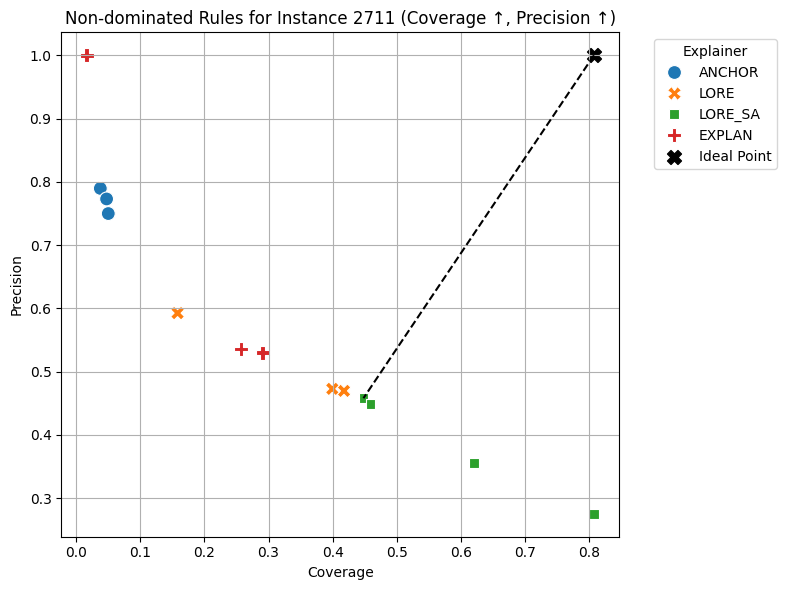

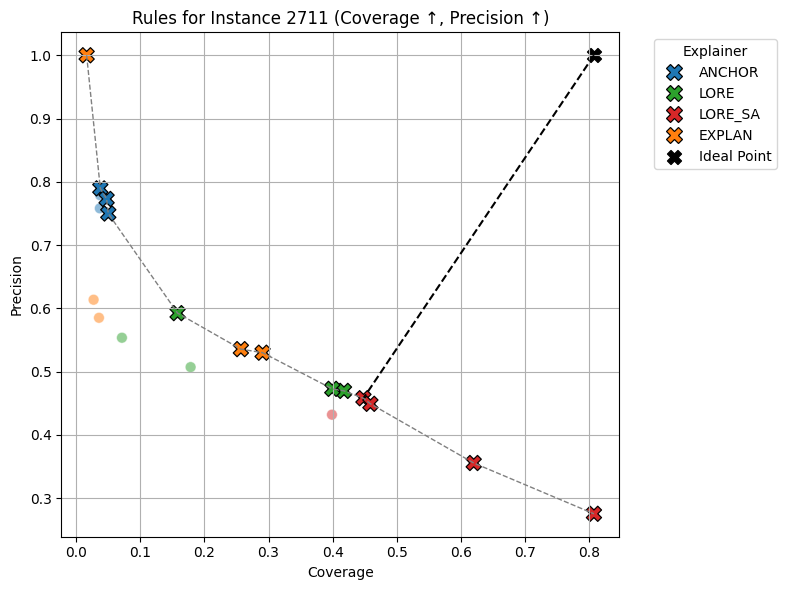

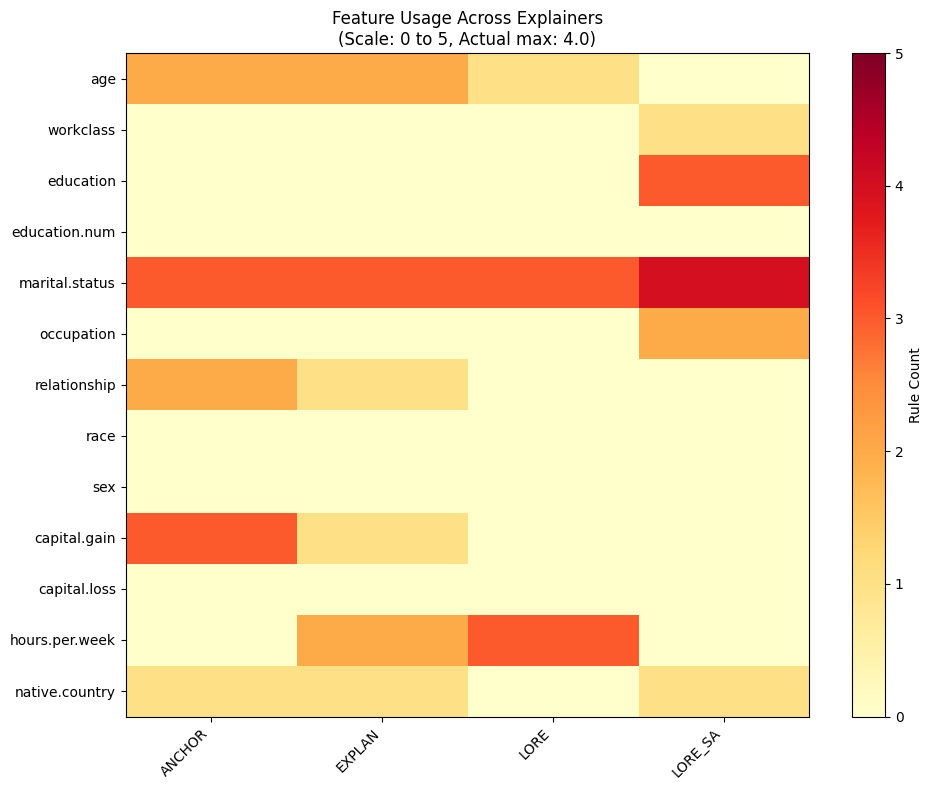

### Rules for Instance 2711, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.92239, Pre: 1.0, Len: 0.27512)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,2711,ANCHOR,ANCHOR2,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.050150,0.156130,0.749780,3,0,1.443910,False,2.841608
1,2711,ANCHOR,ANCHOR3,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.037730,0.123700,0.789530,4,0,1.646410,False,3.815355
2,2711,ANCHOR,ANCHOR4,IF education = Bachelors AND hours.per.week > 40.0 AND relationship = Husband THEN class = >50K,0.036990,0.116410,0.758010,3,1,3.226080,False,2.851865
3,2711,ANCHOR,ANCHOR5,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.047520,0.152490,0.772850,4,1,3.195240,False,3.810390
4,2711,LORE,LORE1,IF hours.per.week > 30.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.417690,0.814170,0.469430,2,0,34.782970,False,1.807879
5,2711,LORE,LORE2,IF age > 29.0 AND hours.per.week > 41.331659 AND marital.status = Married-civ-spouse THEN class = >50K,0.158210,0.389140,0.592350,3,0,35.483390,False,2.806333
6,2711,LORE,LORE3,IF hours.per.week > 37.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.399440,0.783930,0.472650,2,0,35.601840,False,1.809000
7,2711,LORE,LORE4,IF age > 35.0 AND hours.per.week > 40.0 THEN class = >50K,0.178530,0.375840,0.507000,2,0,35.216800,False,1.875360
8,2711,LORE,LORE5,IF hours.per.week > 51.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.071430,0.164150,0.553440,2,0,36.064610,False,1.936377
9,2711,LORE_SA,LORE_SA2,IF education != 7th-8th AND education != 5th-6th AND marital.status != Divorced AND native.country != Puerto-Rico AND occupation != Farming-fishing THEN class = >50K,0.807430,0.922390,0.275120,5,0,12.745840,False,4.780161


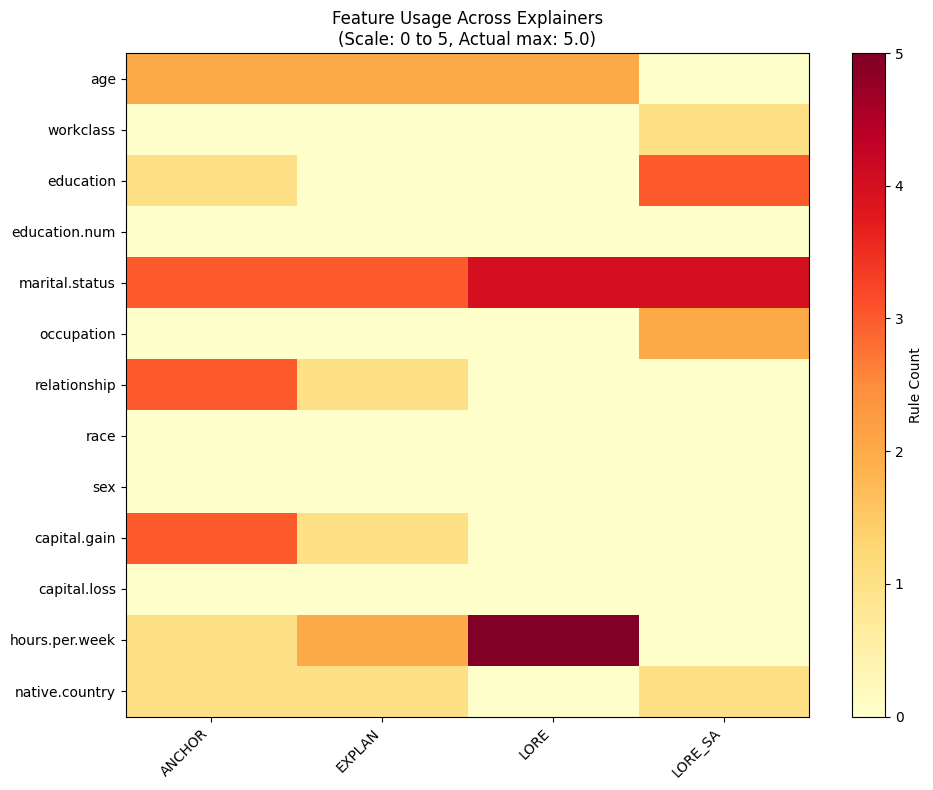

## Instance 12758 (Original: <=50K , Predicted: <=50K)

,Value
age,66.0
workclass,Private
education,HS-grad
education.num,9
marital.status,Widowed
occupation,Priv-house-serv
relationship,Not-in-family
race,White
sex,Female
capital.gain,0.0


### Rules for Instance 12758

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,12758,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.23684,0.28746,0.92145,2,0,1.21022,False
1,12758,ANCHOR,ANCHOR2,IF capital.loss <= 0.0 AND sex = Female AND workclass = Private THEN class = <=50K,0.25614,0.30775,0.91213,3,0,1.23564,False
2,12758,ANCHOR,ANCHOR3,IF capital.gain <= 0.0 AND education.num = 9.0 AND marital.status = Widowed THEN class = <=50K,0.01176,0.01497,0.96642,3,0,1.20652,False
3,12758,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND sex = Female THEN class = <=50K,0.30111,0.36369,0.91695,3,0,1.20473,False
4,12758,ANCHOR,ANCHOR5,IF capital.loss <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.24324,0.28850,0.90043,2,0,1.15592,False
5,12758,LORE,LORE1,IF marital.status = Widowed AND occupation = Priv-house-serv THEN class = <=50K,0.00088,0.00110,0.95000,2,0,35.88729,False
6,12758,LORE,LORE2,IF capital.gain <= 14344.0 AND education.num = 9 AND hours.per.week > 48.0 AND marital.status = Widowed THEN class = <=50K,0.00075,0.00087,0.88235,4,0,37.08829,False
7,12758,LORE,LORE3,IF age > 65.0 AND hours.per.week > 49.073017 AND hours.per.week <= 50.0 THEN class = >50K,0.00140,0.00346,0.59375,3,0,36.58319,False
8,12758,LORE,LORE4,IF age > 46.0 AND marital.status = Widowed THEN class = <=50K,0.02536,0.03057,0.91522,2,0,36.92265,False
9,12758,LORE,LORE5,IF age <= 66.0 AND capital.gain <= 5013.0 AND hours.per.week > 45.0 AND marital.status = Widowed AND occupation = Priv-house-serv THEN class = <=50K,0.00000,0.00000,0.00000,5,0,36.43282,False


### Rules for Instance 12758, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,12758,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.23684,0.28746,0.92145,2,0,1.21022,False
1,12758,ANCHOR,ANCHOR2,IF capital.loss <= 0.0 AND sex = Female AND workclass = Private THEN class = <=50K,0.25614,0.30775,0.91213,3,0,1.23564,False
2,12758,ANCHOR,ANCHOR3,IF capital.gain <= 0.0 AND education.num = 9.0 AND marital.status = Widowed THEN class = <=50K,0.01176,0.01497,0.96642,3,0,1.20652,False
3,12758,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND sex = Female THEN class = <=50K,0.30111,0.36369,0.91695,3,0,1.20473,False
4,12758,ANCHOR,ANCHOR5,IF capital.loss <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.24324,0.28850,0.90043,2,0,1.15592,False
5,12758,LORE,LORE1,IF marital.status = Widowed AND occupation = Priv-house-serv THEN class = <=50K,0.00088,0.00110,0.95000,2,0,35.88729,False
6,12758,LORE,LORE2,IF capital.gain <= 14344.0 AND education.num = 9 AND hours.per.week > 48.0 AND marital.status = Widowed THEN class = <=50K,0.00075,0.00087,0.88235,4,0,37.08829,False
7,12758,LORE,LORE4,IF age > 46.0 AND marital.status = Widowed THEN class = <=50K,0.02536,0.03057,0.91522,2,0,36.92265,False
8,12758,LORE,LORE5,IF age <= 66.0 AND capital.gain <= 5013.0 AND hours.per.week > 45.0 AND marital.status = Widowed AND occupation = Priv-house-serv THEN class = <=50K,0.00000,0.00000,0.00000,5,0,36.43282,False
9,12758,LORE_SA,LORE_SA1,IF capital.gain <= 7609.24658203125 AND capital.loss <= 2488.4227905273438 AND education.num != 12 AND education.num != 14 AND hours.per.week <= 82.70868682861328 AND marital.status = Widowed AND occupation != Tech-support AND occupation != Prof-specialty AND relationship != Wife THEN class = <=50K,0.02040,0.02537,0.94409,9,0,10.40044,False


### Rules for Instance 12758, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,12758,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.23684,0.28746,0.92145,2,0,1.21022,False
1,12758,ANCHOR,ANCHOR2,IF capital.loss <= 0.0 AND sex = Female AND workclass = Private THEN class = <=50K,0.25614,0.30775,0.91213,3,0,1.23564,False
2,12758,ANCHOR,ANCHOR3,IF capital.gain <= 0.0 AND education.num = 9.0 AND marital.status = Widowed THEN class = <=50K,0.01176,0.01497,0.96642,3,0,1.20652,False
3,12758,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND sex = Female THEN class = <=50K,0.30111,0.36369,0.91695,3,0,1.20473,False
4,12758,ANCHOR,ANCHOR5,IF capital.loss <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.24324,0.28850,0.90043,2,0,1.15592,False
5,12758,LORE,LORE4,IF age > 46.0 AND marital.status = Widowed THEN class = <=50K,0.02536,0.03057,0.91522,2,0,36.92265,False
6,12758,LORE_SA,LORE_SA1,IF capital.gain <= 7609.24658203125 AND capital.loss <= 2488.4227905273438 AND education.num != 12 AND education.num != 14 AND hours.per.week <= 82.70868682861328 AND marital.status = Widowed AND occupation != Tech-support AND occupation != Prof-specialty AND relationship != Wife THEN class = <=50K,0.02040,0.02537,0.94409,9,0,10.40044,False
7,12758,LORE_SA,LORE_SA3,IF capital.gain <= 6285.06494140625 AND capital.loss <= 1436.1173706054688 AND marital.status = Widowed AND occupation != Exec-managerial AND occupation != Tech-support THEN class = <=50K,0.02549,0.03208,0.95525,5,0,11.32839,False
8,12758,LORE_SA,LORE_SA4,IF capital.gain <= 7670.983154296875 AND capital.loss <= 2612.3441162109375 AND education != Doctorate AND education.num = 9 AND occupation != Tech-support AND occupation != Machine-op-inspct THEN class = <=50K,0.27847,0.31295,0.85316,6,0,11.97125,False
9,12758,EXPLAN,EXPLAN1,IF age > 48.678384 THEN class = <=50K,0.23276,0.20453,0.66711,1,0,0.88558,False


### Rules for Instance 12758, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.30111, Pre: 0.96642)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,12758,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.236840,0.287460,0.921450,2,0,1.210220,False,0.078441
1,12758,ANCHOR,ANCHOR3,IF capital.gain <= 0.0 AND education.num = 9.0 AND marital.status = Widowed THEN class = <=50K,0.011760,0.014970,0.966420,3,0,1.206520,False,0.289350
2,12758,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND sex = Female THEN class = <=50K,0.301110,0.363690,0.916950,3,0,1.204730,False,0.049470
3,12758,LORE_SA,LORE_SA3,IF capital.gain <= 6285.06494140625 AND capital.loss <= 1436.1173706054688 AND marital.status = Widowed AND occupation != Exec-managerial AND occupation != Tech-support THEN class = <=50K,0.025490,0.032080,0.955250,5,0,11.328390,False,0.275846


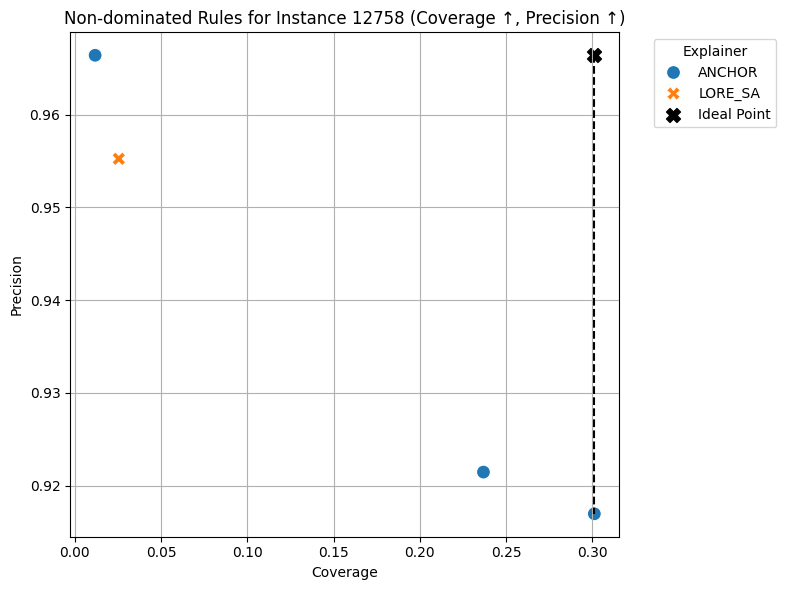

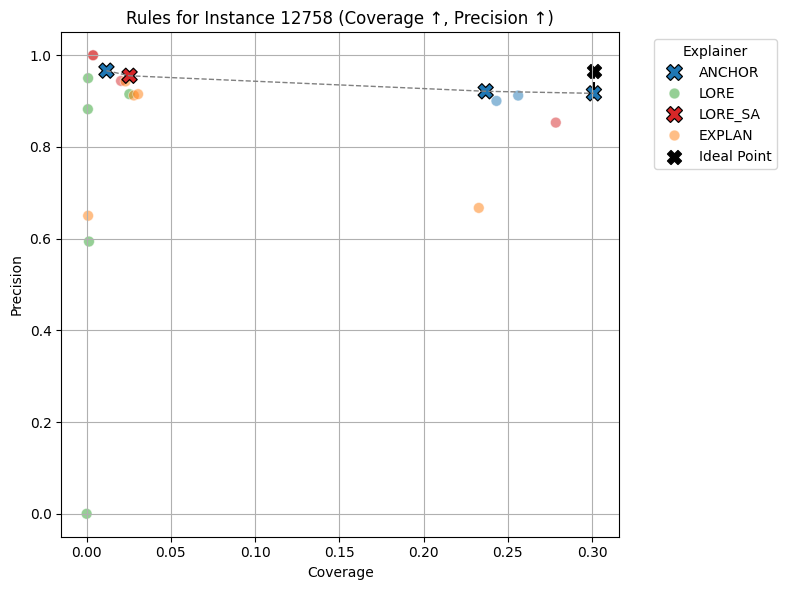

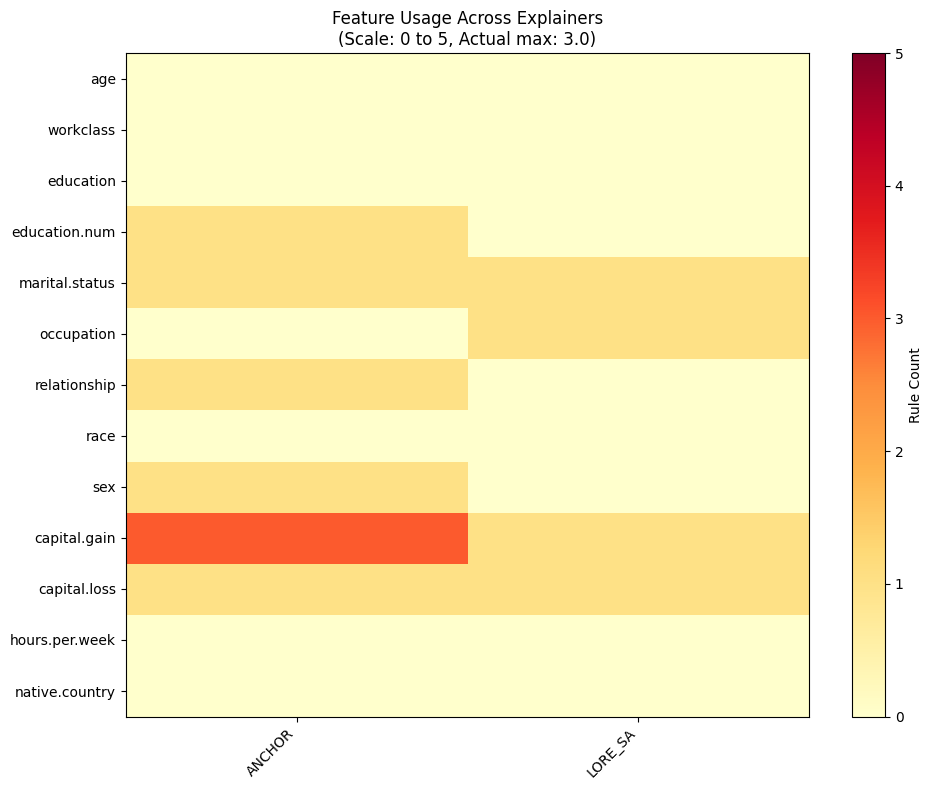

### Rules for Instance 12758, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.36369, Pre: 0.96642, Len: 0.66711)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,12758,ANCHOR,ANCHOR1,IF capital.gain <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.236840,0.287460,0.921450,2,0,1.210220,False,1.335825
1,12758,ANCHOR,ANCHOR3,IF capital.gain <= 0.0 AND education.num = 9.0 AND marital.status = Widowed THEN class = <=50K,0.011760,0.014970,0.966420,3,0,1.206520,False,2.358809
2,12758,ANCHOR,ANCHOR4,IF capital.gain <= 0.0 AND capital.loss <= 0.0 AND sex = Female THEN class = <=50K,0.301110,0.363690,0.916950,3,0,1.204730,False,2.333414
3,12758,ANCHOR,ANCHOR5,IF capital.loss <= 0.0 AND relationship = Not-in-family THEN class = <=50K,0.243240,0.288500,0.900430,2,0,1.155920,False,1.336639
4,12758,LORE_SA,LORE_SA3,IF capital.gain <= 6285.06494140625 AND capital.loss <= 1436.1173706054688 AND marital.status = Widowed AND occupation != Exec-managerial AND occupation != Tech-support THEN class = <=50K,0.025490,0.032080,0.955250,5,0,11.328390,False,4.345575
5,12758,EXPLAN,EXPLAN1,IF age > 48.678384 THEN class = <=50K,0.232760,0.204530,0.667110,1,0,0.885580,False,0.475115
6,12758,EXPLAN,EXPLAN3,IF age > 40.0 AND marital.status = Widowed AND sex = Female THEN class = <=50K,0.023080,0.028670,0.942970,3,0,1.531730,False,2.356940
7,12758,EXPLAN,EXPLAN5,IF marital.status = Widowed THEN class = <=50K,0.030540,0.036810,0.915230,1,0,1.142380,False,0.469347


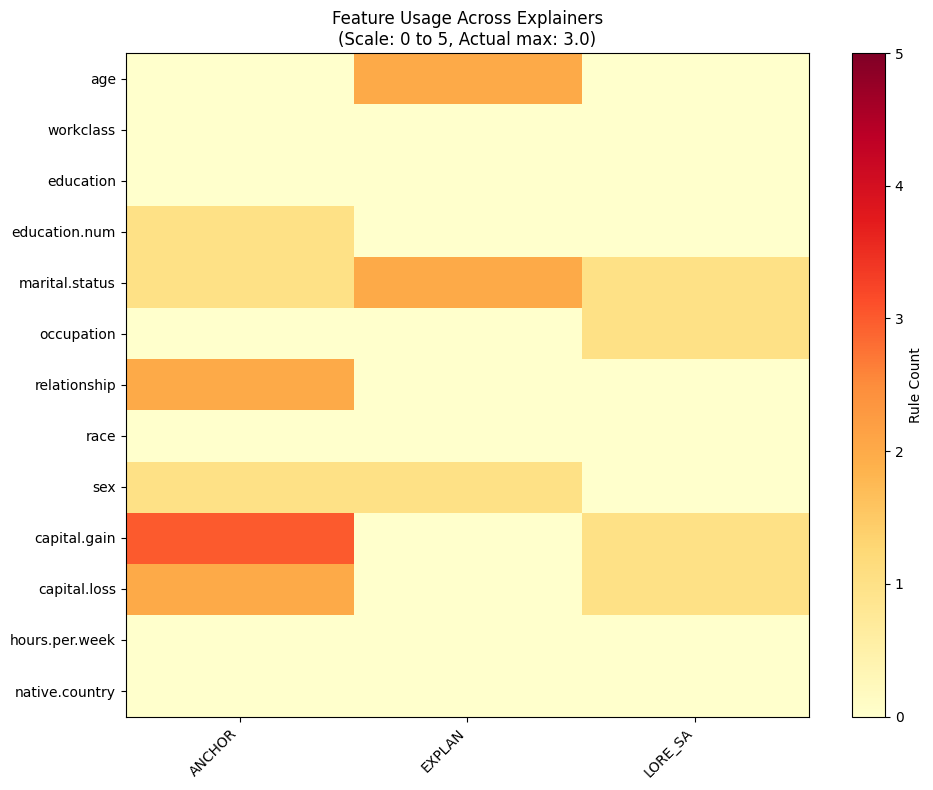

## Instance 5759 (Original: <=50K , Predicted: <=50K)

,Value
age,17.0
workclass,Private
education,10th
education.num,6
marital.status,Never-married
occupation,Prof-specialty
relationship,Own-child
race,White
sex,Male
capital.gain,0.0


### Rules for Instance 5759

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,5759,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,0,0.67913,False
1,5759,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,2,2.33342,False
2,5759,ANCHOR,ANCHOR3,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,0.65986,False
3,5759,ANCHOR,ANCHOR4,IF hours.per.week <= 40.0 AND marital.status = Never-married THEN class = <=50K,0.26378,0.33931,0.97655,2,0,0.74604,False
4,5759,ANCHOR,ANCHOR5,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,8,6.66622,True
5,5759,LORE,LORE1,IF capital.gain <= 7943.805271 THEN class = <=50K,0.97310,0.99919,0.77952,1,0,36.81768,False
6,5759,LORE,LORE2,IF capital.gain <= 9562.0 AND marital.status = Never-married THEN class = <=50K,0.32384,0.41155,0.96477,2,0,39.82240,False
7,5759,LORE,LORE3,IF age <= 29.0 AND marital.status = Never-married THEN class = <=50K,0.21995,0.28585,0.98663,2,0,39.34692,False
8,5759,LORE,LORE4,IF capital.gain <= 0.0 AND hours.per.week <= 48.0 AND relationship = Own-child THEN class = <=50K,0.14110,0.18471,0.99378,3,0,41.20327,False
9,5759,LORE,LORE5,IF age <= 44.0 AND capital.gain <= 12715.492389 THEN class = <=50K,0.67326,0.72808,0.82098,2,0,42.05301,False


### Rules for Instance 5759, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,5759,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,0,0.67913,False
1,5759,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,2,2.33342,False
2,5759,ANCHOR,ANCHOR3,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,0.65986,False
3,5759,ANCHOR,ANCHOR4,IF hours.per.week <= 40.0 AND marital.status = Never-married THEN class = <=50K,0.26378,0.33931,0.97655,2,0,0.74604,False
4,5759,ANCHOR,ANCHOR5,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,8,6.66622,True
5,5759,LORE,LORE1,IF capital.gain <= 7943.805271 THEN class = <=50K,0.97310,0.99919,0.77952,1,0,36.81768,False
6,5759,LORE,LORE2,IF capital.gain <= 9562.0 AND marital.status = Never-married THEN class = <=50K,0.32384,0.41155,0.96477,2,0,39.82240,False
7,5759,LORE,LORE3,IF age <= 29.0 AND marital.status = Never-married THEN class = <=50K,0.21995,0.28585,0.98663,2,0,39.34692,False
8,5759,LORE,LORE4,IF capital.gain <= 0.0 AND hours.per.week <= 48.0 AND relationship = Own-child THEN class = <=50K,0.14110,0.18471,0.99378,3,0,41.20327,False
9,5759,LORE,LORE5,IF age <= 44.0 AND capital.gain <= 12715.492389 THEN class = <=50K,0.67326,0.72808,0.82098,2,0,42.05301,False


### Rules for Instance 5759, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,5759,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,0,0.67913,False
1,5759,ANCHOR,ANCHOR2,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,2,2.33342,False
2,5759,ANCHOR,ANCHOR3,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,0.65986,False
3,5759,ANCHOR,ANCHOR4,IF hours.per.week <= 40.0 AND marital.status = Never-married THEN class = <=50K,0.26378,0.33931,0.97655,2,0,0.74604,False
4,5759,ANCHOR,ANCHOR5,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,8,6.66622,True
5,5759,LORE,LORE1,IF capital.gain <= 7943.805271 THEN class = <=50K,0.97310,0.99919,0.77952,1,0,36.81768,False
6,5759,LORE,LORE2,IF capital.gain <= 9562.0 AND marital.status = Never-married THEN class = <=50K,0.32384,0.41155,0.96477,2,0,39.82240,False
7,5759,LORE,LORE3,IF age <= 29.0 AND marital.status = Never-married THEN class = <=50K,0.21995,0.28585,0.98663,2,0,39.34692,False
8,5759,LORE,LORE4,IF capital.gain <= 0.0 AND hours.per.week <= 48.0 AND relationship = Own-child THEN class = <=50K,0.14110,0.18471,0.99378,3,0,41.20327,False
9,5759,LORE,LORE5,IF age <= 44.0 AND capital.gain <= 12715.492389 THEN class = <=50K,0.67326,0.72808,0.82098,2,0,42.05301,False


### Rules for Instance 5759, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.9731, Pre: 1.0)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,5759,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.282120,0.360520,0.970140,2,0,0.679130,False,0.691625
1,5759,ANCHOR,ANCHOR4,IF hours.per.week <= 40.0 AND marital.status = Never-married THEN class = <=50K,0.263780,0.339310,0.976550,2,0,0.746040,False,0.709708
2,5759,LORE,LORE1,IF capital.gain <= 7943.805271 THEN class = <=50K,0.973100,0.999190,0.779520,1,0,36.817680,False,0.220480
3,5759,LORE,LORE2,IF capital.gain <= 9562.0 AND marital.status = Never-married THEN class = <=50K,0.323840,0.411550,0.964770,2,0,39.822400,False,0.650215
4,5759,LORE,LORE3,IF age <= 29.0 AND marital.status = Never-married THEN class = <=50K,0.219950,0.285850,0.986630,2,0,39.346920,False,0.753269
5,5759,LORE,LORE4,IF capital.gain <= 0.0 AND hours.per.week <= 48.0 AND relationship = Own-child THEN class = <=50K,0.141100,0.184710,0.993780,3,0,41.203270,False,0.832023
6,5759,LORE,LORE5,IF age <= 44.0 AND capital.gain <= 12715.492389 THEN class = <=50K,0.673260,0.728080,0.820980,2,0,42.053010,False,0.349217
7,5759,LORE_SA,LORE_SA1,IF age <= 17.117141723632812 AND capital.gain <= 13118.125 AND hours.per.week <= 96.21634292602539 THEN class = <=50K,0.011930,0.015720,1.000000,3,0,12.905190,False,0.961170
8,5759,LORE_SA,LORE_SA2,IF capital.gain <= 12074.603607177734 AND capital.loss <= 10.076154708862305 THEN class = <=50K,0.930680,0.969020,0.790450,2,0,11.686880,False,0.213801
9,5759,LORE_SA,LORE_SA4,IF age <= 30.558768272399902 AND capital.gain <= 16463.423828125 AND capital.loss <= 4106.3427734375 AND native.country != France THEN class = <=50K,0.324680,0.400620,0.936760,4,0,12.616660,False,0.651497


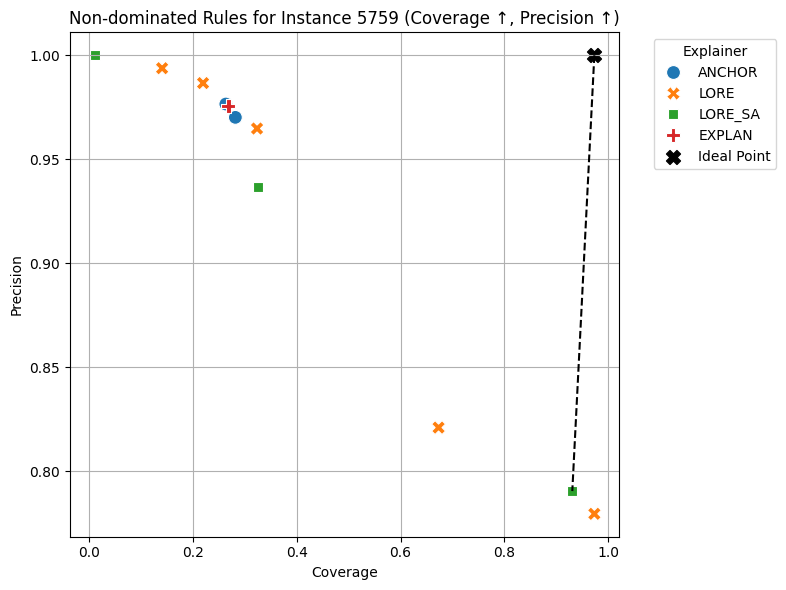

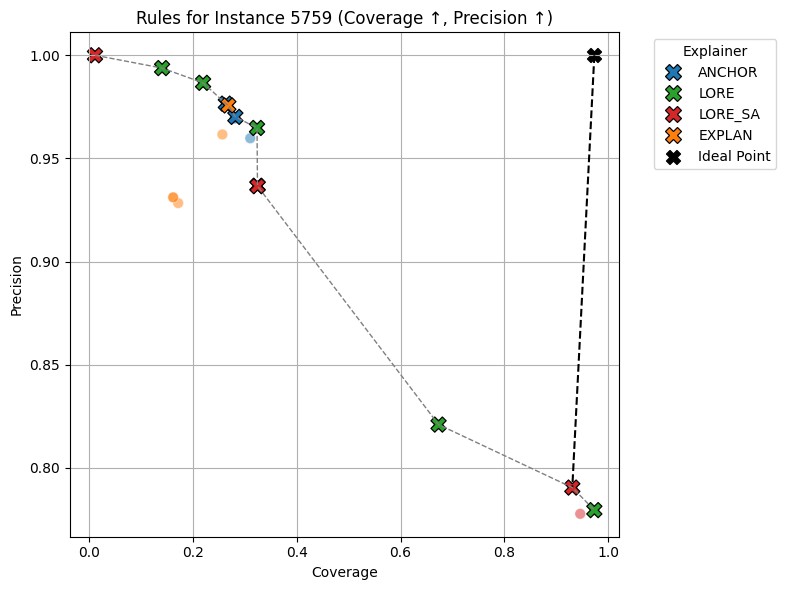

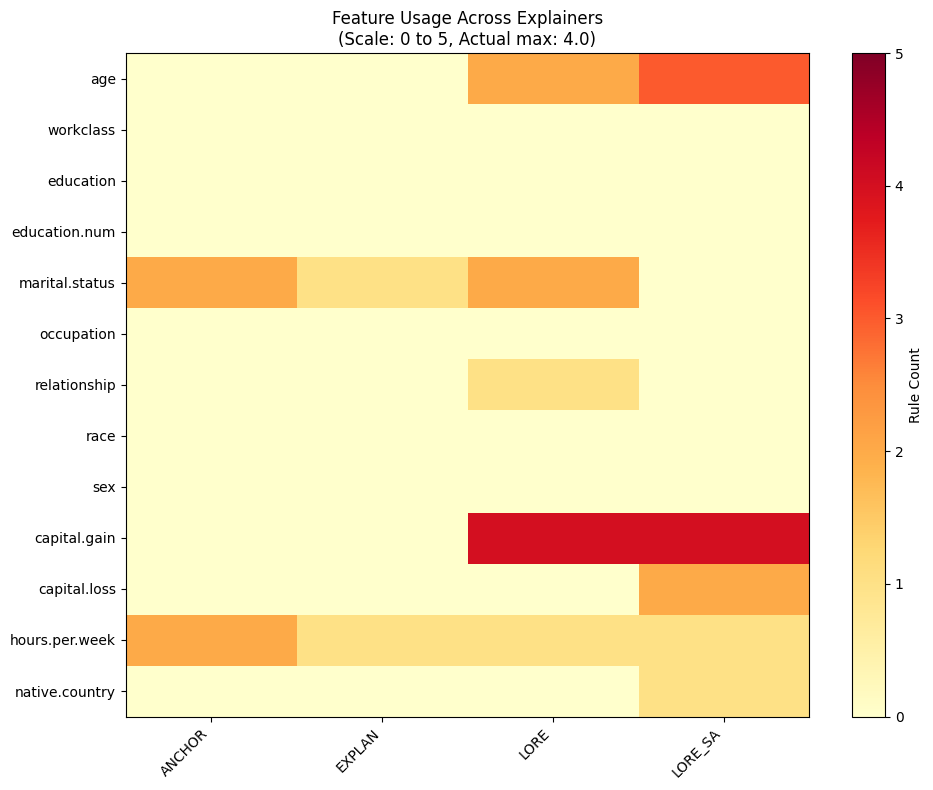

### Rules for Instance 5759, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.99919, Pre: 1.0, Len: 0.77952)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,5759,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.282120,0.360520,0.970140,2,0,0.679130,False,1.377811
1,5759,ANCHOR,ANCHOR4,IF hours.per.week <= 40.0 AND marital.status = Never-married THEN class = <=50K,0.263780,0.339310,0.976550,2,0,0.746040,False,1.387647
2,5759,LORE,LORE1,IF capital.gain <= 7943.805271 THEN class = <=50K,0.973100,0.999190,0.779520,1,0,36.817680,False,0.311806
3,5759,LORE,LORE2,IF capital.gain <= 9562.0 AND marital.status = Never-married THEN class = <=50K,0.323840,0.411550,0.964770,2,0,39.822400,False,1.355040
4,5759,LORE,LORE3,IF age <= 29.0 AND marital.status = Never-married THEN class = <=50K,0.219950,0.285850,0.986630,2,0,39.346920,False,1.413720
5,5759,LORE,LORE4,IF capital.gain <= 0.0 AND hours.per.week <= 48.0 AND relationship = Own-child THEN class = <=50K,0.141100,0.184710,0.993780,3,0,41.203270,False,2.365153
6,5759,LORE,LORE5,IF age <= 44.0 AND capital.gain <= 12715.492389 THEN class = <=50K,0.673260,0.728080,0.820980,2,0,42.053010,False,1.262981
7,5759,LORE_SA,LORE_SA1,IF age <= 17.117141723632812 AND capital.gain <= 13118.125 AND hours.per.week <= 96.21634292602539 THEN class = <=50K,0.011930,0.015720,1.000000,3,0,12.905190,False,2.428527
8,5759,LORE_SA,LORE_SA2,IF capital.gain <= 12074.603607177734 AND capital.loss <= 10.076154708862305 THEN class = <=50K,0.930680,0.969020,0.790450,2,0,11.686880,False,1.238706
9,5759,EXPLAN,EXPLAN2,IF hours.per.week <= 33.0 THEN class = <=50K,0.172080,0.210430,0.928350,1,0,0.959900,False,0.822124


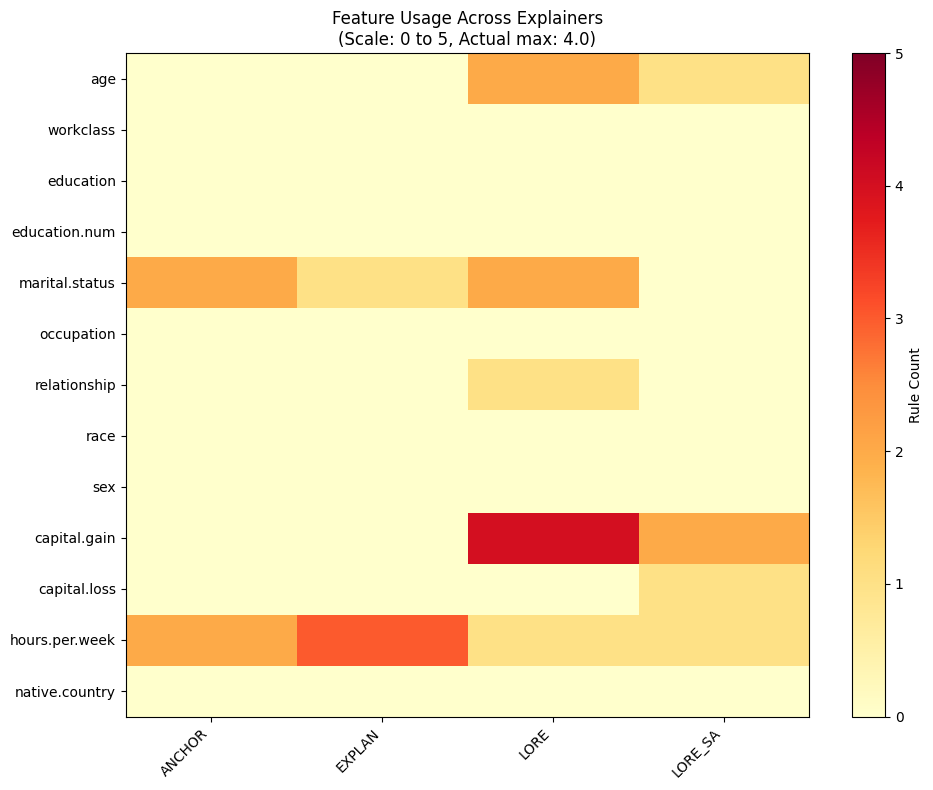

## Instance 20 (Original: >50K , Predicted: >50K)

,Value
age,37.0
workclass,Private
education,Bachelors
education.num,13
marital.status,Never-married
occupation,Exec-managerial
relationship,Not-in-family
race,White
sex,Male
capital.gain,0.0


### Rules for Instance 20

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,20,ANCHOR,ANCHOR1,IF age > 28.0 AND capital.loss > 0.0 AND education = Bachelors AND education.num = 13.0 AND sex = Male THEN class = >50K,0.00728,0.02314,0.76506,5,0,3.96311,False
1,20,ANCHOR,ANCHOR2,IF age > 28.0 AND capital.loss > 0.0 AND education = Bachelors AND education.num = 13.0 AND race = White AND sex = Male THEN class = >50K,0.00649,0.02132,0.79054,6,1,8.59991,False
2,20,ANCHOR,ANCHOR3,IF age > 28.0 AND capital.loss > 0.0 AND education.num = 13.0 AND native.country = United-States AND sex = Male THEN class = >50K,0.00680,0.02223,0.78710,5,1,7.45924,False
3,20,ANCHOR,ANCHOR4,IF age > 28.0 AND capital.loss > 0.0 AND occupation = Exec-managerial AND sex = Male THEN class = >50K,0.00693,0.02350,0.81646,4,0,3.93474,False
4,20,ANCHOR,ANCHOR5,IF capital.loss > 0.0 AND education = Bachelors AND education.num = 13.0 AND occupation = Exec-managerial AND sex = Male THEN class = >50K,0.00312,0.01002,0.77465,5,0,4.48951,False
5,20,LORE,LORE1,IF hours.per.week > 35.0 AND occupation = Exec-managerial THEN class = >50K,0.11179,0.23866,0.51413,2,0,40.04799,False
6,20,LORE,LORE2,IF hours.per.week > 20.0 AND occupation = Exec-managerial THEN class = >50K,0.11916,0.24631,0.49779,2,0,39.71722,False
7,20,LORE,LORE3,IF age > 36.0 AND age <= 37.0 THEN class = <=50K,0.02633,0.02248,0.64833,2,0,39.33583,False
8,20,LORE,LORE4,IF age <= 38.0 AND capital.loss > 2001.0 AND education.num = 13 AND hours.per.week > 16.0 AND marital.status = Never-married AND occupation = Exec-managerial AND sex = Male THEN class = >50K,0.00004,0.00018,1.00000,7,0,39.04209,False
9,20,LORE,LORE5,IF capital.loss > 511.799897 AND hours.per.week > 35.0 AND occupation = Exec-managerial THEN class = >50K,0.00803,0.02569,0.77049,3,0,40.22019,False


### Rules for Instance 20, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,20,ANCHOR,ANCHOR1,IF age > 28.0 AND capital.loss > 0.0 AND education = Bachelors AND education.num = 13.0 AND sex = Male THEN class = >50K,0.00728,0.02314,0.76506,5,0,3.96311,False
1,20,ANCHOR,ANCHOR2,IF age > 28.0 AND capital.loss > 0.0 AND education = Bachelors AND education.num = 13.0 AND race = White AND sex = Male THEN class = >50K,0.00649,0.02132,0.79054,6,1,8.59991,False
2,20,ANCHOR,ANCHOR3,IF age > 28.0 AND capital.loss > 0.0 AND education.num = 13.0 AND native.country = United-States AND sex = Male THEN class = >50K,0.00680,0.02223,0.78710,5,1,7.45924,False
3,20,ANCHOR,ANCHOR4,IF age > 28.0 AND capital.loss > 0.0 AND occupation = Exec-managerial AND sex = Male THEN class = >50K,0.00693,0.02350,0.81646,4,0,3.93474,False
4,20,ANCHOR,ANCHOR5,IF capital.loss > 0.0 AND education = Bachelors AND education.num = 13.0 AND occupation = Exec-managerial AND sex = Male THEN class = >50K,0.00312,0.01002,0.77465,5,0,4.48951,False
5,20,LORE,LORE1,IF hours.per.week > 35.0 AND occupation = Exec-managerial THEN class = >50K,0.11179,0.23866,0.51413,2,0,40.04799,False
6,20,LORE,LORE2,IF hours.per.week > 20.0 AND occupation = Exec-managerial THEN class = >50K,0.11916,0.24631,0.49779,2,0,39.71722,False
7,20,LORE,LORE4,IF age <= 38.0 AND capital.loss > 2001.0 AND education.num = 13 AND hours.per.week > 16.0 AND marital.status = Never-married AND occupation = Exec-managerial AND sex = Male THEN class = >50K,0.00004,0.00018,1.00000,7,0,39.04209,False
8,20,LORE,LORE5,IF capital.loss > 511.799897 AND hours.per.week > 35.0 AND occupation = Exec-managerial THEN class = >50K,0.00803,0.02569,0.77049,3,0,40.22019,False
9,20,LORE_SA,LORE_SA1,IF age > 23.47642230987549 AND capital.loss > 442.19447326660156 AND education != 7th-8th AND education != 5th-6th AND education.num = 13 AND hours.per.week > 24.660411834716797 AND occupation != Farming-fishing AND occupation != Priv-house-serv AND occupation != Armed-Forces AND occupation != Transport-moving AND occupation != Machine-op-inspct THEN class = >50K,0.00908,0.02587,0.68599,11,0,13.11982,False


### Rules for Instance 20, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,20,LORE,LORE1,IF hours.per.week > 35.0 AND occupation = Exec-managerial THEN class = >50K,0.11179,0.23866,0.51413,2,0,40.04799,False
1,20,LORE,LORE2,IF hours.per.week > 20.0 AND occupation = Exec-managerial THEN class = >50K,0.11916,0.24631,0.49779,2,0,39.71722,False
2,20,LORE_SA,LORE_SA2,IF education != 10th AND education != 7th-8th AND education != 1st-4th AND education != 5th-6th AND education.num != 4 AND education.num != 6 AND education.num != 3 AND education.num != 9 AND hours.per.week > 9.722675323486328 AND occupation != Priv-house-serv AND occupation != Other-service AND occupation != Farming-fishing AND occupation != Armed-Forces AND race != Other AND race != Asian-Pac-Islander AND relationship != Other-relative THEN class = >50K,0.50895,0.71580,0.33871,16,0,13.37303,False
3,20,LORE_SA,LORE_SA5,IF education != 12th AND education != 9th AND education != 5th-6th AND education.num != 3 AND education.num != 4 AND education.num != 6 AND education.num != 7 AND education.num != 1 AND education.num != 5 AND native.country != Cuba AND native.country != South AND occupation != Farming-fishing AND occupation != Priv-house-serv AND occupation != Armed-Forces AND relationship != Own-child AND workclass != Without-pay THEN class = >50K,0.72231,0.94698,0.31574,16,0,13.64701,False


### Rules for Instance 20, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.72231, Pre: 0.51413)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,20,LORE,LORE1,IF hours.per.week > 35.0 AND occupation = Exec-managerial THEN class = >50K,0.111790,0.238660,0.514130,2,0,40.047990,False,0.610520
1,20,LORE,LORE2,IF hours.per.week > 20.0 AND occupation = Exec-managerial THEN class = >50K,0.119160,0.246310,0.497790,2,0,39.717220,False,0.603371
2,20,LORE_SA,LORE_SA2,IF education != 10th AND education != 7th-8th AND education != 1st-4th AND education != 5th-6th AND education.num != 4 AND education.num != 6 AND education.num != 3 AND education.num != 9 AND hours.per.week > 9.722675323486328 AND occupation != Priv-house-serv AND occupation != Other-service AND occupation != Farming-fishing AND occupation != Armed-Forces AND race != Other AND race != Asian-Pac-Islander AND relationship != Other-relative THEN class = >50K,0.508950,0.715800,0.338710,16,0,13.373030,False,0.276215
3,20,LORE_SA,LORE_SA5,IF education != 12th AND education != 9th AND education != 5th-6th AND education.num != 3 AND education.num != 4 AND education.num != 6 AND education.num != 7 AND education.num != 1 AND education.num != 5 AND native.country != Cuba AND native.country != South AND occupation != Farming-fishing AND occupation != Priv-house-serv AND occupation != Armed-Forces AND relationship != Own-child AND workclass != Without-pay THEN class = >50K,0.722310,0.946980,0.315740,16,0,13.647010,False,0.198390


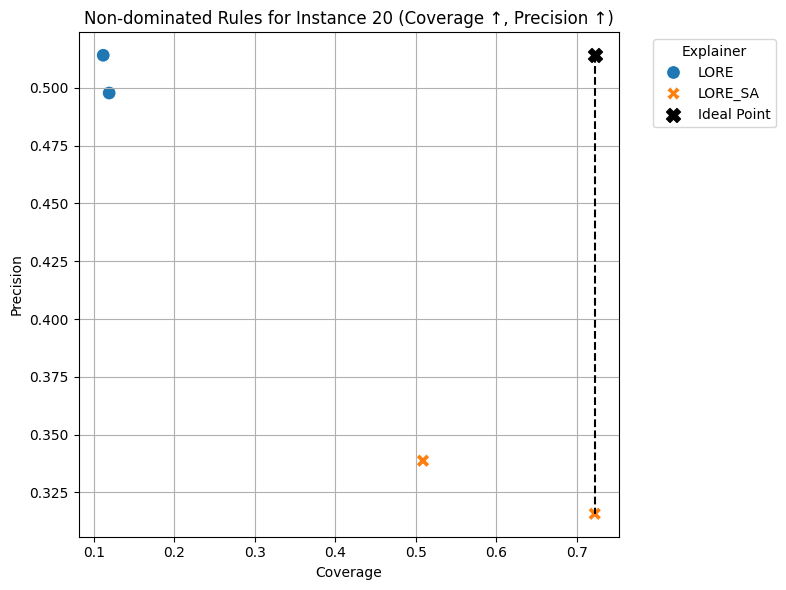

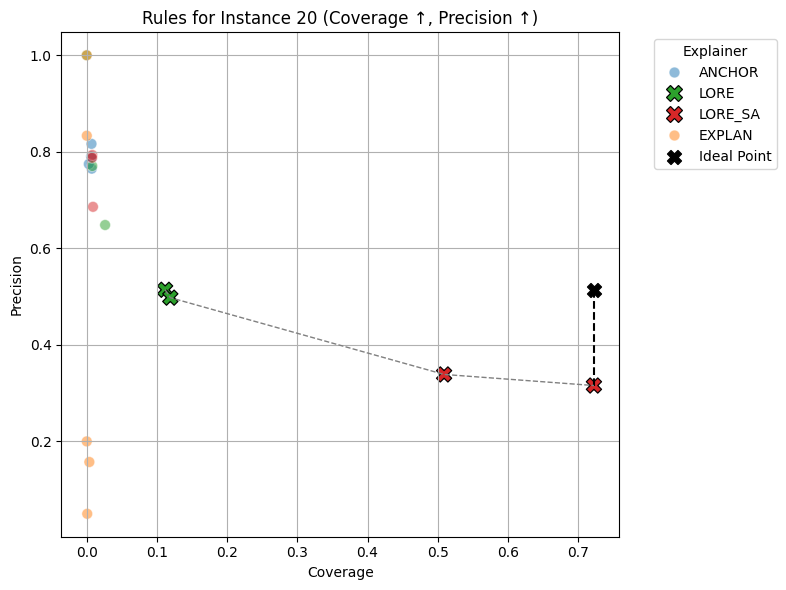

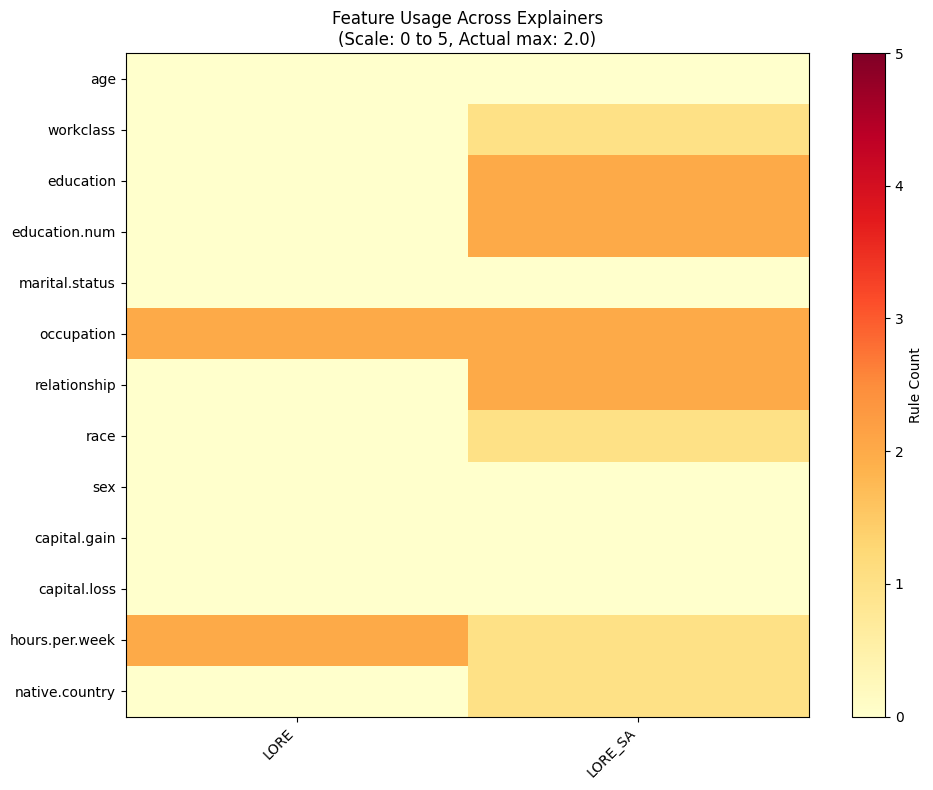

### Rules for Instance 20, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.94698, Pre: 0.51413, Len: 0.31574)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,20,LORE,LORE1,IF hours.per.week > 35.0 AND occupation = Exec-managerial THEN class = >50K,0.111790,0.238660,0.514130,2,0,40.047990,False,1.827142
1,20,LORE,LORE2,IF hours.per.week > 20.0 AND occupation = Exec-managerial THEN class = >50K,0.119160,0.246310,0.497790,2,0,39.717220,False,1.824263
2,20,LORE_SA,LORE_SA2,IF education != 10th AND education != 7th-8th AND education != 1st-4th AND education != 5th-6th AND education.num != 4 AND education.num != 6 AND education.num != 3 AND education.num != 9 AND hours.per.week > 9.722675323486328 AND occupation != Priv-house-serv AND occupation != Other-service AND occupation != Farming-fishing AND occupation != Armed-Forces AND race != Other AND race != Asian-Pac-Islander AND relationship != Other-relative THEN class = >50K,0.508950,0.715800,0.338710,16,0,13.373030,False,15.686945
3,20,LORE_SA,LORE_SA5,IF education != 12th AND education != 9th AND education != 5th-6th AND education.num != 3 AND education.num != 4 AND education.num != 6 AND education.num != 7 AND education.num != 1 AND education.num != 5 AND native.country != Cuba AND native.country != South AND occupation != Farming-fishing AND occupation != Priv-house-serv AND occupation != Armed-Forces AND relationship != Own-child AND workclass != Without-pay THEN class = >50K,0.722310,0.946980,0.315740,16,0,13.647010,False,15.685515


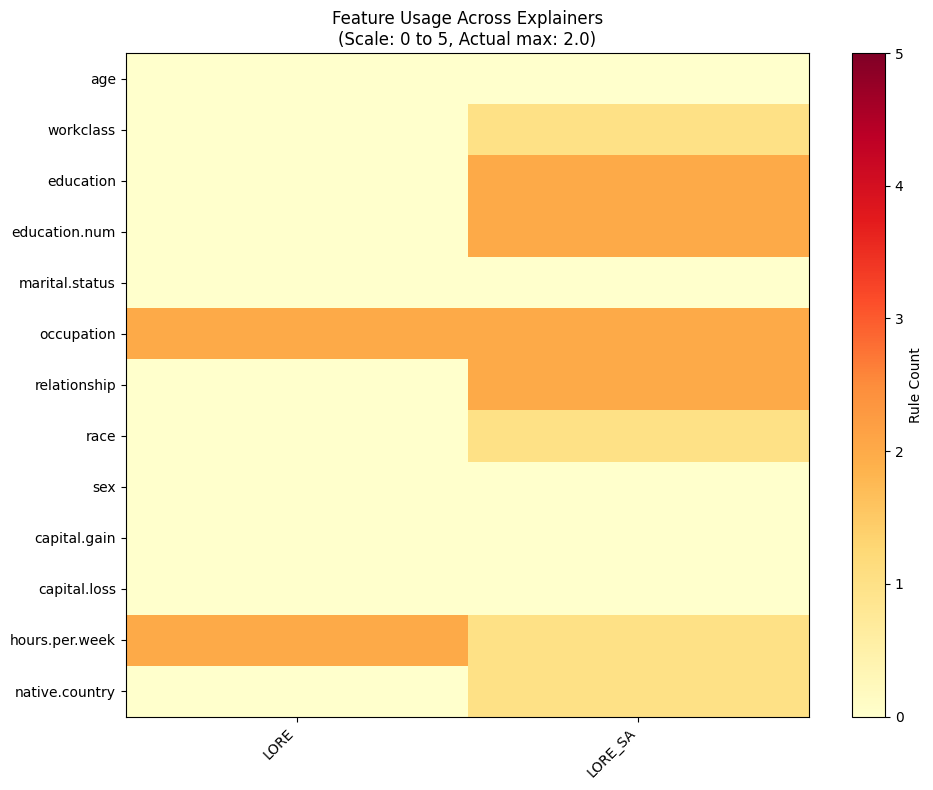

## Instance 1808 (Original: >50K , Predicted: >50K)

,Value
age,59.0
workclass,Self-emp-not-inc
education,Bachelors
education.num,13
marital.status,Married-civ-spouse
occupation,Sales
relationship,Husband
race,White
sex,Male
capital.gain,15024.0


### Rules for Instance 1808

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,1808,ANCHOR,ANCHOR1,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.03747,0.12115,0.77869,4,0,1.98501,False
1,1808,ANCHOR,ANCHOR2,IF education = Bachelors AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.07678,0.21825,0.68457,3,0,2.21978,False
2,1808,ANCHOR,ANCHOR3,IF education.num = 13.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.07446,0.20969,0.67826,3,0,2.01365,False
3,1808,ANCHOR,ANCHOR4,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.04752,0.15249,0.77285,4,0,2.33443,False
4,1808,ANCHOR,ANCHOR5,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.05015,0.15613,0.74978,3,0,2.48725,False
5,1808,LORE,LORE1,IF capital.gain > 5178.0 THEN class = >50K,0.04602,0.18054,0.94471,1,0,41.82833,False
6,1808,LORE,LORE2,IF capital.gain > 5032.148007 THEN class = >50K,0.04923,0.19366,0.94742,1,0,40.58834,False
7,1808,LORE,LORE3,IF capital.gain > 7298.0 THEN class = >50K,0.03637,0.14757,0.97708,1,0,38.05615,False
8,1808,LORE,LORE4,IF capital.gain > 6877.730245 THEN class = >50K,0.04379,0.17836,0.98096,1,0,39.72625,False
9,1808,LORE,LORE5,IF capital.gain > 7688.0 THEN class = >50K,0.02694,0.10931,0.97720,1,0,38.24186,False


### Rules for Instance 1808, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,1808,ANCHOR,ANCHOR1,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.03747,0.12115,0.77869,4,0,1.98501,False
1,1808,ANCHOR,ANCHOR2,IF education = Bachelors AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.07678,0.21825,0.68457,3,0,2.21978,False
2,1808,ANCHOR,ANCHOR3,IF education.num = 13.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.07446,0.20969,0.67826,3,0,2.01365,False
3,1808,ANCHOR,ANCHOR4,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.04752,0.15249,0.77285,4,0,2.33443,False
4,1808,ANCHOR,ANCHOR5,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.05015,0.15613,0.74978,3,0,2.48725,False
5,1808,LORE,LORE1,IF capital.gain > 5178.0 THEN class = >50K,0.04602,0.18054,0.94471,1,0,41.82833,False
6,1808,LORE,LORE2,IF capital.gain > 5032.148007 THEN class = >50K,0.04923,0.19366,0.94742,1,0,40.58834,False
7,1808,LORE,LORE3,IF capital.gain > 7298.0 THEN class = >50K,0.03637,0.14757,0.97708,1,0,38.05615,False
8,1808,LORE,LORE4,IF capital.gain > 6877.730245 THEN class = >50K,0.04379,0.17836,0.98096,1,0,39.72625,False
9,1808,LORE,LORE5,IF capital.gain > 7688.0 THEN class = >50K,0.02694,0.10931,0.97720,1,0,38.24186,False


### Rules for Instance 1808, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,1808,ANCHOR,ANCHOR1,IF age > 37.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.03747,0.12115,0.77869,4,0,1.98501,False
1,1808,ANCHOR,ANCHOR2,IF education = Bachelors AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.07678,0.21825,0.68457,3,0,2.21978,False
2,1808,ANCHOR,ANCHOR3,IF education.num = 13.0 AND marital.status = Married-civ-spouse AND sex = Male THEN class = >50K,0.07446,0.20969,0.67826,3,0,2.01365,False
3,1808,ANCHOR,ANCHOR4,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.04752,0.15249,0.77285,4,0,2.33443,False
4,1808,ANCHOR,ANCHOR5,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.05015,0.15613,0.74978,3,0,2.48725,False
5,1808,LORE,LORE1,IF capital.gain > 5178.0 THEN class = >50K,0.04602,0.18054,0.94471,1,0,41.82833,False
6,1808,LORE,LORE2,IF capital.gain > 5032.148007 THEN class = >50K,0.04923,0.19366,0.94742,1,0,40.58834,False
7,1808,LORE,LORE3,IF capital.gain > 7298.0 THEN class = >50K,0.03637,0.14757,0.97708,1,0,38.05615,False
8,1808,LORE,LORE4,IF capital.gain > 6877.730245 THEN class = >50K,0.04379,0.17836,0.98096,1,0,39.72625,False
9,1808,LORE,LORE5,IF capital.gain > 7688.0 THEN class = >50K,0.02694,0.10931,0.97720,1,0,38.24186,False


### Rules for Instance 1808, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.97771, Pre: 0.98096)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,1808,ANCHOR,ANCHOR2,IF education = Bachelors AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.076780,0.218250,0.684570,3,0,2.219780,False,0.948431
1,1808,ANCHOR,ANCHOR5,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.050150,0.156130,0.749780,3,0,2.487250,False,0.955935
2,1808,LORE,LORE2,IF capital.gain > 5032.148007 THEN class = >50K,0.049230,0.193660,0.947420,1,0,40.588340,False,0.929086
3,1808,LORE,LORE4,IF capital.gain > 6877.730245 THEN class = >50K,0.043790,0.178360,0.980960,1,0,39.726250,False,0.933920
4,1808,LORE_SA,LORE_SA1,IF education != 1st-4th AND education != 9th AND education != Assoc-voc AND native.country != Portugal AND occupation != Handlers-cleaners AND race != Amer-Indian-Eskimo THEN class = >50K,0.887900,0.932410,0.252900,6,0,13.107080,False,0.733578
5,1808,LORE_SA,LORE_SA2,IF education.num != 2 AND marital.status = Married-civ-spouse THEN class = >50K,0.456700,0.854620,0.450670,2,0,13.674050,False,0.743410
6,1808,LORE_SA,LORE_SA3,IF education.num != 4 AND occupation != Farming-fishing AND occupation != Transport-moving AND relationship != Own-child THEN class = >50K,0.761670,0.934960,0.295620,4,0,13.377040,False,0.718585
7,1808,LORE_SA,LORE_SA4,IF education != 7th-8th AND education.num != 1 AND native.country != Outlying-US(Guam-USVI-etc) THEN class = >50K,0.977710,0.995810,0.245290,3,0,13.233730,False,0.735670
8,1808,LORE_SA,LORE_SA5,IF education != 7th-8th AND education.num != 2 AND native.country != Trinadad&Tobago AND occupation != Other-service THEN class = >50K,0.877020,0.978320,0.268650,4,0,13.431730,False,0.719391
9,1808,EXPLAN,EXPLAN5,IF age > 44.089302 AND hours.per.week > 35.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.162690,0.361450,0.535060,3,0,4.970660,False,0.929023


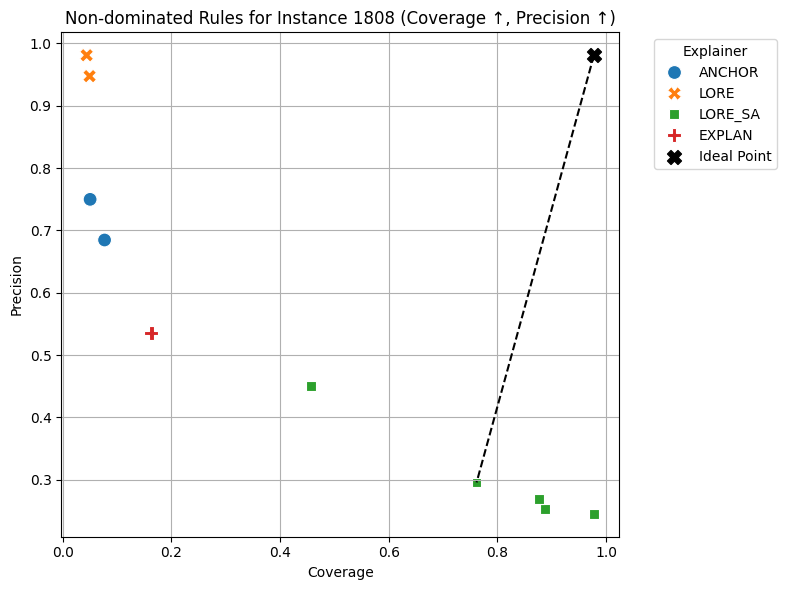

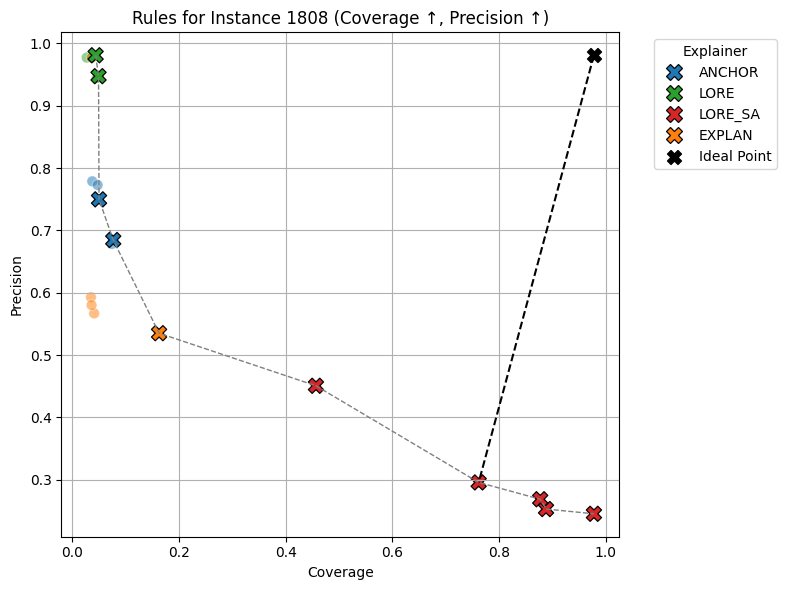

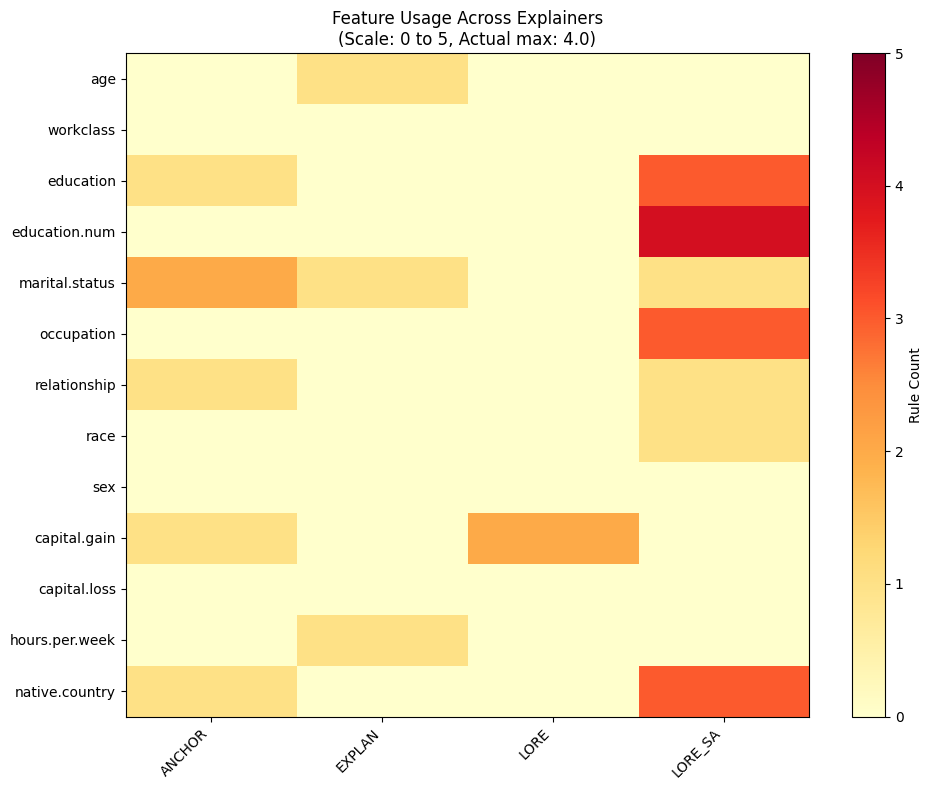

### Rules for Instance 1808, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.99581, Pre: 0.98096, Len: 0.24529)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,1808,ANCHOR,ANCHOR2,IF education = Bachelors AND marital.status = Married-civ-spouse AND native.country = United-States THEN class = >50K,0.076780,0.218250,0.684570,3,0,2.219780,False,2.877651
1,1808,LORE,LORE2,IF capital.gain > 5032.148007 THEN class = >50K,0.049230,0.193660,0.947420,1,0,40.588340,False,1.101888
2,1808,LORE,LORE4,IF capital.gain > 6877.730245 THEN class = >50K,0.043790,0.178360,0.980960,1,0,39.726250,False,1.112570
3,1808,LORE_SA,LORE_SA2,IF education.num != 2 AND marital.status = Married-civ-spouse THEN class = >50K,0.456700,0.854620,0.450670,2,0,13.674050,False,1.838518
4,1808,LORE_SA,LORE_SA3,IF education.num != 4 AND occupation != Farming-fishing AND occupation != Transport-moving AND relationship != Own-child THEN class = >50K,0.761670,0.934960,0.295620,4,0,13.377040,False,3.817229
5,1808,LORE_SA,LORE_SA4,IF education != 7th-8th AND education.num != 1 AND native.country != Outlying-US(Guam-USVI-etc) THEN class = >50K,0.977710,0.995810,0.245290,3,0,13.233730,False,2.851252
6,1808,LORE_SA,LORE_SA5,IF education != 7th-8th AND education.num != 2 AND native.country != Trinadad&Tobago AND occupation != Other-service THEN class = >50K,0.877020,0.978320,0.268650,4,0,13.431730,False,3.821719
7,1808,EXPLAN,EXPLAN5,IF age > 44.089302 AND hours.per.week > 35.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.162690,0.361450,0.535060,3,0,4.970660,False,2.861759


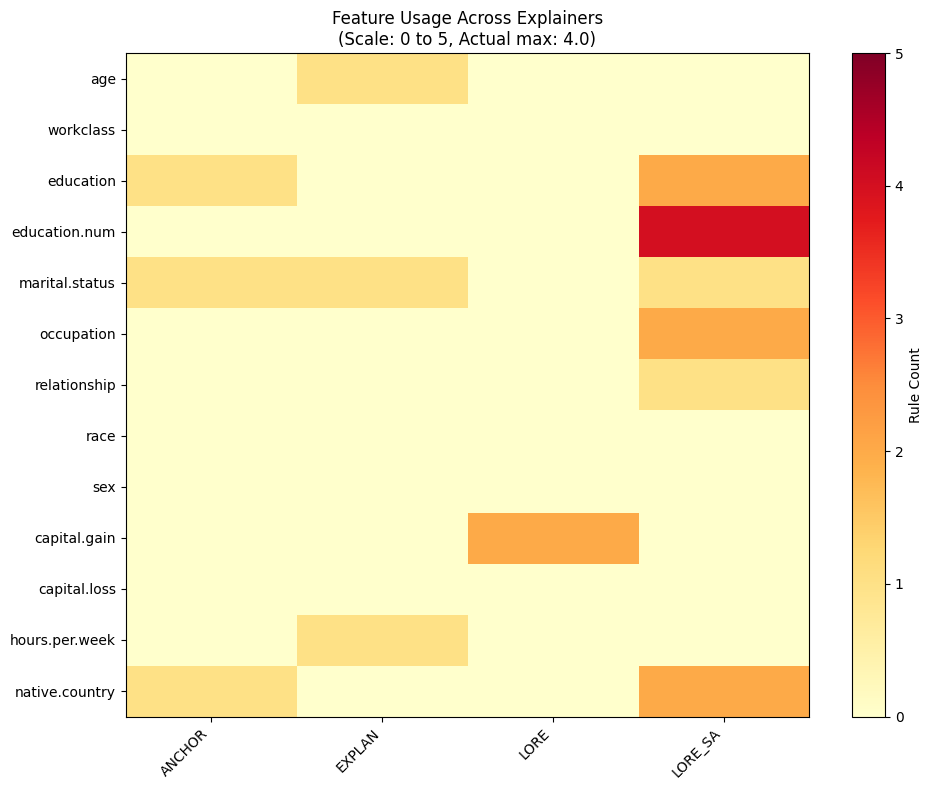

## Instance 12191 (Original: <=50K , Predicted: <=50K)

,Value
age,22.0
workclass,Private
education,HS-grad
education.num,9
marital.status,Never-married
occupation,Sales
relationship,Not-in-family
race,White
sex,Female
capital.gain,0.0


### Rules for Instance 12191

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,12191,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,0,1.04261,False
1,12191,ANCHOR,ANCHOR2,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,1.07711,False
2,12191,ANCHOR,ANCHOR3,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,3,3.60752,False
3,12191,ANCHOR,ANCHOR4,IF age <= 47.0 AND capital.loss <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.30208,0.38294,0.96238,3,6,5.99055,False
4,12191,ANCHOR,ANCHOR5,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,1,1.85472,True
5,12191,LORE,LORE1,IF capital.gain <= 0.0 THEN class = <=50K,0.91598,0.95810,0.79408,1,0,38.33321,False
6,12191,LORE,LORE2,IF capital.gain <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.31336,0.39912,0.96696,2,0,38.72681,False
7,12191,LORE,LORE3,IF age <= 23.0 AND capital.gain <= 5178.0 THEN class = <=50K,0.14483,0.19008,0.99636,2,0,39.51059,False
8,12191,LORE,LORE4,IF age <= 38.0 AND capital.gain <= 4787.0 AND marital.status = Never-married THEN class = <=50K,0.28124,0.36260,0.97878,3,0,39.56369,False
9,12191,LORE,LORE5,IF age <= 30.550636 AND capital.gain <= 0.0 THEN class = <=50K,0.31243,0.38901,0.94523,2,0,39.38699,False


### Rules for Instance 12191, Correct Prediction

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,12191,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,0,1.04261,False
1,12191,ANCHOR,ANCHOR2,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,1.07711,False
2,12191,ANCHOR,ANCHOR3,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,3,3.60752,False
3,12191,ANCHOR,ANCHOR4,IF age <= 47.0 AND capital.loss <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.30208,0.38294,0.96238,3,6,5.99055,False
4,12191,ANCHOR,ANCHOR5,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,1,1.85472,True
5,12191,LORE,LORE1,IF capital.gain <= 0.0 THEN class = <=50K,0.91598,0.95810,0.79408,1,0,38.33321,False
6,12191,LORE,LORE2,IF capital.gain <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.31336,0.39912,0.96696,2,0,38.72681,False
7,12191,LORE,LORE3,IF age <= 23.0 AND capital.gain <= 5178.0 THEN class = <=50K,0.14483,0.19008,0.99636,2,0,39.51059,False
8,12191,LORE,LORE4,IF age <= 38.0 AND capital.gain <= 4787.0 AND marital.status = Never-married THEN class = <=50K,0.28124,0.36260,0.97878,3,0,39.56369,False
9,12191,LORE,LORE5,IF age <= 30.550636 AND capital.gain <= 0.0 THEN class = <=50K,0.31243,0.38901,0.94523,2,0,39.38699,False


### Rules for Instance 12191, Min_treshold (Cov 0.01, Cov_class 0.01, Pre 0.01)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,12191,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,0,1.04261,False
1,12191,ANCHOR,ANCHOR2,IF age <= 37.0 AND marital.status = Never-married THEN class = <=50K,0.28102,0.35884,0.96940,2,0,1.07711,False
2,12191,ANCHOR,ANCHOR3,IF age <= 47.0 AND marital.status = Never-married THEN class = <=50K,0.31081,0.39294,0.95977,2,3,3.60752,False
3,12191,ANCHOR,ANCHOR4,IF age <= 47.0 AND capital.loss <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.30208,0.38294,0.96238,3,6,5.99055,False
4,12191,ANCHOR,ANCHOR5,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.28212,0.36052,0.97014,2,1,1.85472,True
5,12191,LORE,LORE1,IF capital.gain <= 0.0 THEN class = <=50K,0.91598,0.95810,0.79408,1,0,38.33321,False
6,12191,LORE,LORE2,IF capital.gain <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.31336,0.39912,0.96696,2,0,38.72681,False
7,12191,LORE,LORE3,IF age <= 23.0 AND capital.gain <= 5178.0 THEN class = <=50K,0.14483,0.19008,0.99636,2,0,39.51059,False
8,12191,LORE,LORE4,IF age <= 38.0 AND capital.gain <= 4787.0 AND marital.status = Never-married THEN class = <=50K,0.28124,0.36260,0.97878,3,0,39.56369,False
9,12191,LORE,LORE5,IF age <= 30.550636 AND capital.gain <= 0.0 THEN class = <=50K,0.31243,0.38901,0.94523,2,0,39.38699,False


### Rules for Instance 12191, Non-dominated (Cov↑, Pre↑), Ideal (Cov: 0.91598, Pre: 0.99845)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,12191,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.282120,0.360520,0.970140,2,0,1.042610,False,0.634492
1,12191,ANCHOR,ANCHOR5,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.282120,0.360520,0.970140,2,1,1.854720,True,0.634492
2,12191,LORE,LORE1,IF capital.gain <= 0.0 THEN class = <=50K,0.915980,0.958100,0.794080,1,0,38.333210,False,0.204370
3,12191,LORE,LORE2,IF capital.gain <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.313360,0.399120,0.966960,2,0,38.726810,False,0.603442
4,12191,LORE,LORE3,IF age <= 23.0 AND capital.gain <= 5178.0 THEN class = <=50K,0.144830,0.190080,0.996360,2,0,39.510590,False,0.771153
5,12191,LORE,LORE4,IF age <= 38.0 AND capital.gain <= 4787.0 AND marital.status = Never-married THEN class = <=50K,0.281240,0.362600,0.978780,3,0,39.563690,False,0.635045
6,12191,LORE_SA,LORE_SA1,IF capital.gain <= 14119.2470703125 AND hours.per.week <= 40.177955627441406 AND native.country != Haiti AND occupation != Prof-specialty AND occupation != Exec-managerial THEN class = <=50K,0.509040,0.589440,0.879070,5,0,13.443820,False,0.424089
7,12191,LORE_SA,LORE_SA3,IF capital.gain <= 14931.7275390625 AND marital.status = Never-married AND native.country != Cuba AND relationship != Wife THEN class = <=50K,0.325950,0.410800,0.956790,4,0,18.104410,False,0.591499
8,12191,LORE_SA,LORE_SA5,IF age <= 22.870328903198242 AND capital.gain <= 9999.5615234375 AND education != Doctorate AND marital.status != Married-civ-spouse THEN class = <=50K,0.113420,0.149160,0.998450,4,0,16.406830,False,0.802560


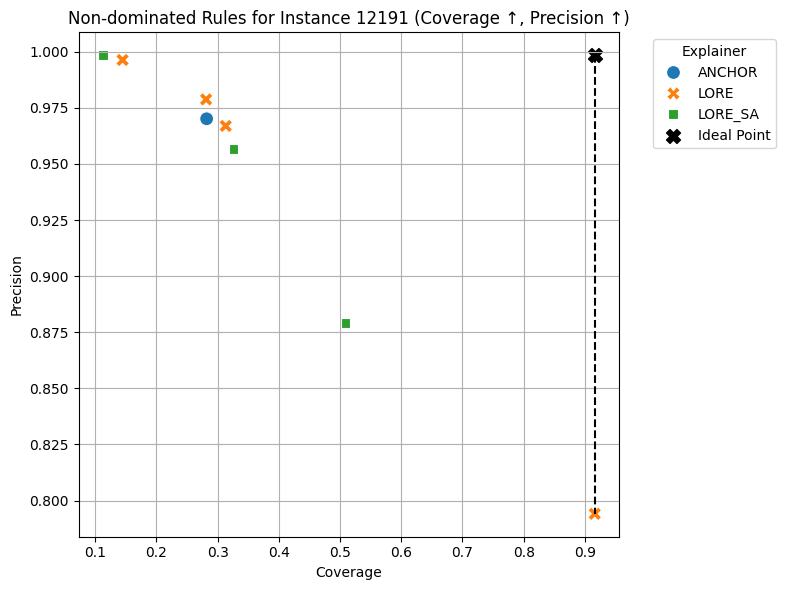

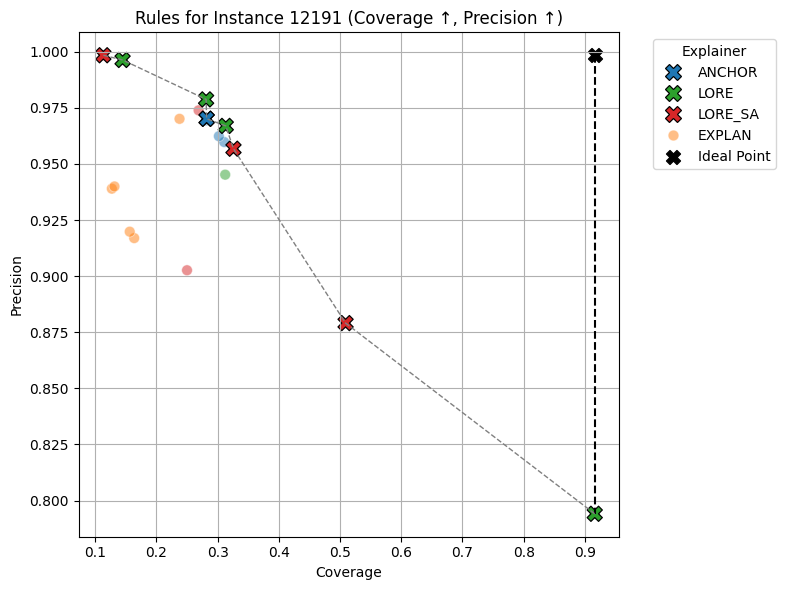

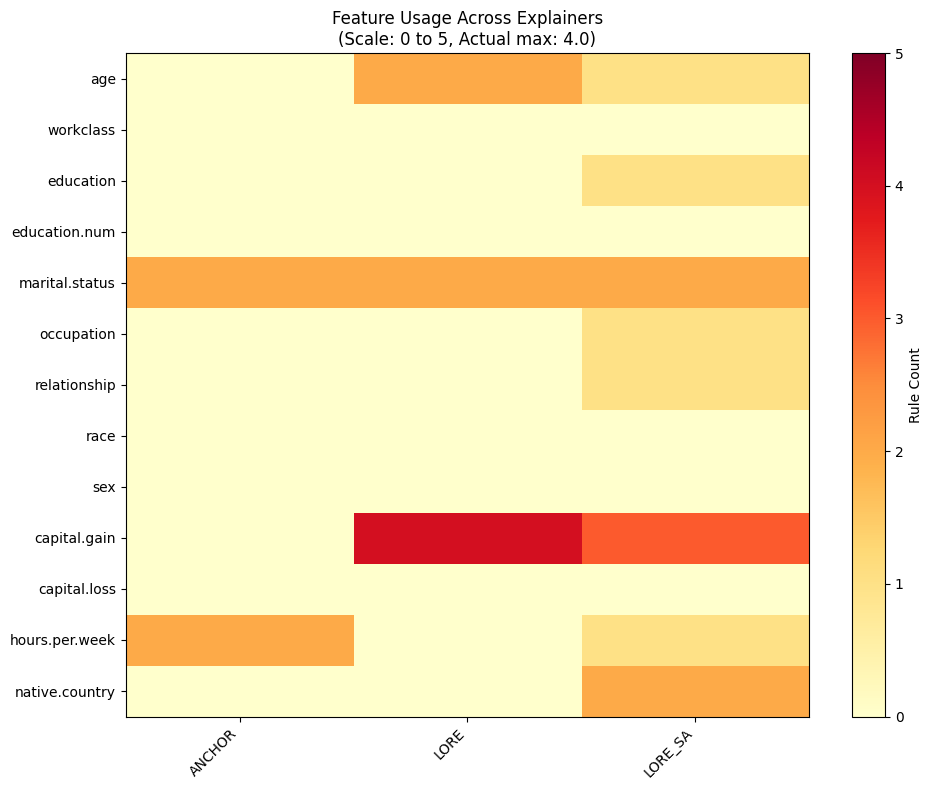

### Rules for Instance 12191, Non-dominated (Cov_class↑, Pre↑, Len↓), Ideal (Cov: 0.9581, Pre: 0.99845, Len: 0.79408)

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit,Distance_idp_eucl
0,12191,ANCHOR,ANCHOR1,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.282120,0.360520,0.970140,2,0,1.042610,False,1.346160
1,12191,ANCHOR,ANCHOR5,IF hours.per.week <= 45.0 AND marital.status = Never-married THEN class = <=50K,0.282120,0.360520,0.970140,2,1,1.854720,True,1.346160
2,12191,LORE,LORE1,IF capital.gain <= 0.0 THEN class = <=50K,0.915980,0.958100,0.794080,1,0,38.333210,False,0.290121
3,12191,LORE,LORE2,IF capital.gain <= 0.0 AND marital.status = Never-married THEN class = <=50K,0.313360,0.399120,0.966960,2,0,38.726810,False,1.329546
4,12191,LORE,LORE3,IF age <= 23.0 AND capital.gain <= 5178.0 THEN class = <=50K,0.144830,0.190080,0.996360,2,0,39.510590,False,1.429721
5,12191,LORE,LORE4,IF age <= 38.0 AND capital.gain <= 4787.0 AND marital.status = Never-married THEN class = <=50K,0.281240,0.362600,0.978780,3,0,39.563690,False,2.284971
6,12191,LORE_SA,LORE_SA1,IF capital.gain <= 14119.2470703125 AND hours.per.week <= 40.177955627441406 AND native.country != Haiti AND occupation != Prof-specialty AND occupation != Exec-managerial THEN class = <=50K,0.509040,0.589440,0.879070,5,0,13.443820,False,4.223734
7,12191,LORE_SA,LORE_SA3,IF capital.gain <= 14931.7275390625 AND marital.status = Never-married AND native.country != Cuba AND relationship != Wife THEN class = <=50K,0.325950,0.410800,0.956790,4,0,18.104410,False,3.252568
8,12191,LORE_SA,LORE_SA5,IF age <= 22.870328903198242 AND capital.gain <= 9999.5615234375 AND education != Doctorate AND marital.status != Married-civ-spouse THEN class = <=50K,0.113420,0.149160,0.998450,4,0,16.406830,False,3.306404


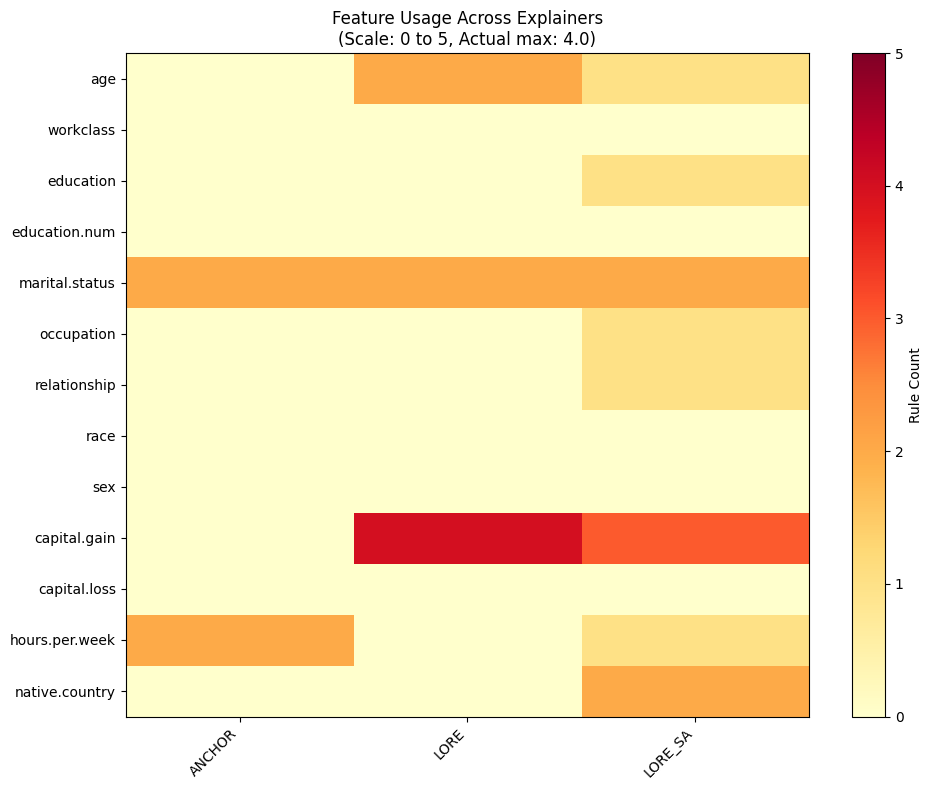

## Instance 3374 (Original: <=50K , Predicted: >50K)

,Value
age,59.0
workclass,Private
education,Some-college
education.num,10
marital.status,Married-civ-spouse
occupation,Sales
relationship,Husband
race,White
sex,Male
capital.gain,4064.0


### Rules for Instance 3374

,Instance_Name,Explainer,Rule_ID,Rule,Cov,Cov_class,Pre,Len,Reject,Elapsed_time,Iter_Limit
0,3374,ANCHOR,ANCHOR1,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND native.country = United-States AND relationship = Husband THEN class = >50K,0.04624,0.14611,0.76091,4,0,5.53648,False
1,3374,ANCHOR,ANCHOR2,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband AND sex = Male THEN class = >50K,0.05015,0.15613,0.74978,4,0,3.98707,False
2,3374,ANCHOR,ANCHOR3,IF capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.05015,0.15613,0.74978,3,0,5.08813,False
3,3374,ANCHOR,ANCHOR4,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband AND sex = Male THEN class = >50K,0.04752,0.15249,0.77285,5,0,4.25054,False
4,3374,ANCHOR,ANCHOR5,IF age > 28.0 AND capital.gain > 0.0 AND marital.status = Married-civ-spouse AND relationship = Husband THEN class = >50K,0.04752,0.15249,0.77285,4,4,15.11682,False
5,3374,LORE,LORE1,IF hours.per.week > 10.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.45240,0.84915,0.45204,2,0,48.45413,False
6,3374,LORE,LORE2,IF age > 23.0 AND age <= 59.0 AND hours.per.week > 32.242271 AND marital.status = Married-civ-spouse THEN class = >50K,0.37697,0.75515,0.48243,4,0,50.62037,False
7,3374,LORE,LORE3,IF hours.per.week > 24.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.43335,0.82948,0.46097,2,0,47.36966,False
8,3374,LORE,LORE4,IF age > 29.0 AND hours.per.week > 20.0 AND hours.per.week <= 40.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.22310,0.39424,0.42557,4,0,48.50996,False
9,3374,LORE,LORE5,IF age > 46.0 AND marital.status = Married-civ-spouse THEN class = >50K,0.16787,0.33412,0.47935,2,0,51.51428,False


### Rules for Instance 3374, Correct Prediction

...

### Average Metrics for Non-Dominated Rules (Cov↑, Pre↑)

,Pre,Cov,Cov_class,Len,Reject,Elapsed_time
EXPLAN,0.800201,0.190748,0.321346,2.569444,0.133333,2.938884
LORE,0.766740,0.322002,0.449556,1.729167,0.000000,37.922694
LORE_SA,0.663391,0.481802,0.613669,5.653704,0.000000,12.621688
ANCHOR,0.867292,0.165588,0.248472,2.761905,0.404762,1.836721
Global_Average,0.765890,0.307194,0.426228,3.315556,0.121111,14.915570


### Average Metrics for Non-Dominated Rules (Cov_class↑, Pre↑, Len↓)

,Pre,Cov,Cov_class,Len,Reject,Elapsed_time
EXPLAN,0.801765,0.167481,0.274924,2.345238,0.114286,2.669176
LORE,0.770007,0.304383,0.423356,1.722917,0.000000,38.046169
LORE_SA,0.663466,0.489983,0.622704,5.546296,0.000000,12.642879
ANCHOR,0.860947,0.169342,0.254293,2.714286,0.428571,1.856175
Global_Average,0.766782,0.296860,0.409539,3.197312,0.122581,14.510733


## Overall Heatmap – Non-dominated Rules (Cov↑, Pre↑)

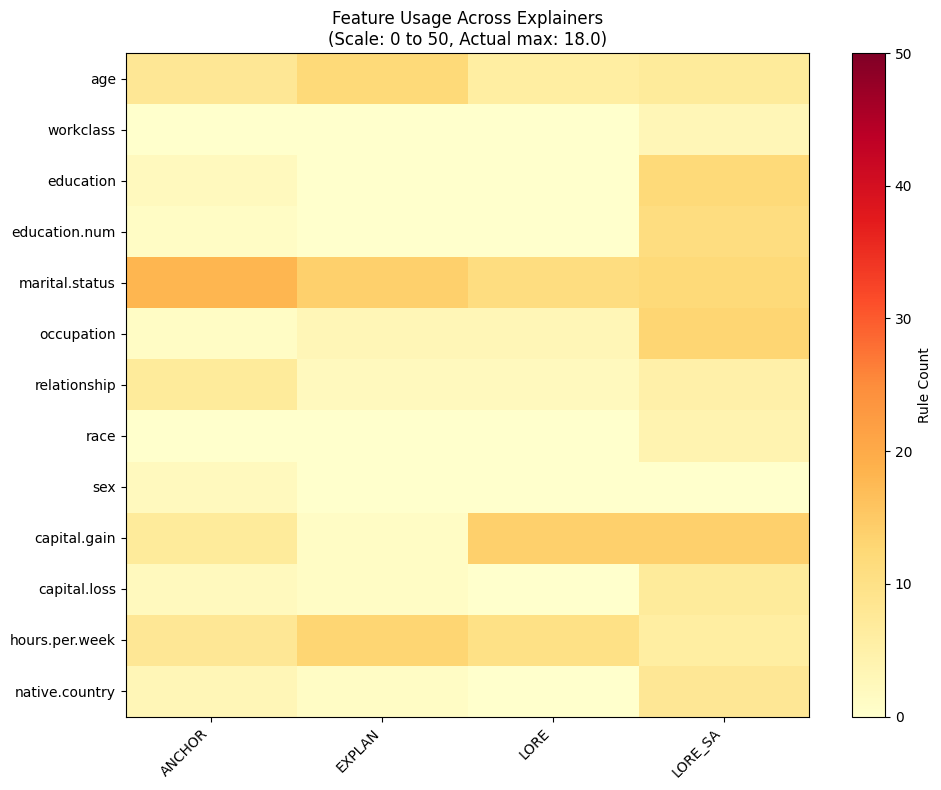

## Overall Heatmap – Non-dominated Rules (Cov_class↑, Pre↑, Len↓)

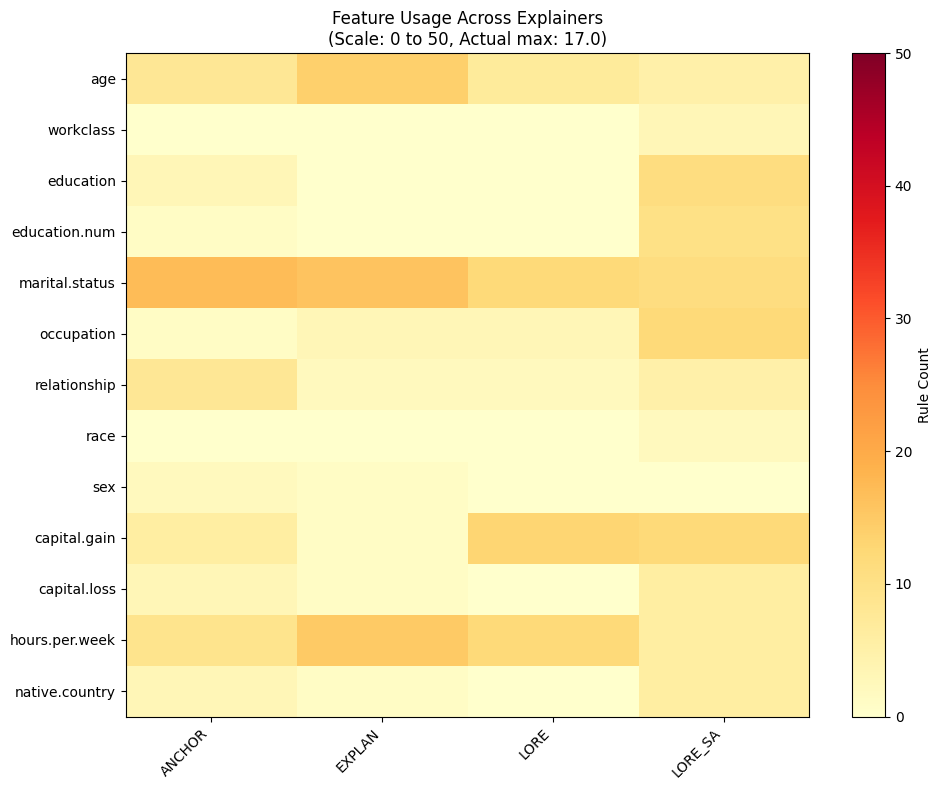

In [88]:
rules_log = "adult_simpleNN_rules_19-23_06-06-2025.txt"
entries_log = "adult_simpleNN_entries_19-23_06-06-2025.txt"
analyze_results(rules_log, entries_log, path="../experiments_log/", min_cov = 0.01, min_cov_class = 0.01, min_pre = 0.01)